<a href="https://colab.research.google.com/github/christianirshool-glitch/Housing_Prices/blob/main/Project_2_Housing_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Load the necessary tools**

In [ ]:
pip install kaggle

In [ ]:
# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move kaggle.json to the .kaggle directory
!mv kaggle.json ~/.kaggle/

# Set permissions (important for security)
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# Download the specific dataset 'yasserh/housing-prices-dataset'
!kaggle datasets download -d yasserh/housing-prices-dataset

# Unzip the downloaded files
import zipfile
import os

# The downloaded file will be named after the dataset slug, e.g., 'housing-prices-dataset.zip'
zip_file_name = 'housing-prices-dataset.zip'

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Extracted {zip_file_name}")
else:
    print(f"Error: {zip_file_name} not found. Check if the download was successful.")

Dataset URL: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset
License(s): CC0-1.0
housing-prices-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracted housing-prices-dataset.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub
import pandas as pd  # Library for data manipulation and analysis
import numpy as np  # Library for data manipulation and mathematical operations
import matplotlib.pyplot as plt  # Library for data visualization
import seaborn as sns  # Library for data visualization
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder  # Library for building ML models
import sys
import importlib

In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
try:
    data = pd.read_csv("Housing.csv") # Corrected path to the extracted CSV
    display(data.head())
except FileNotFoundError:
    print("Housing.csv not found in the current directory. Please check extraction.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# 1. Univariate analysis of the data

**1.1 Dataset Size (size in memory, number of records and attributes, etc.)**


In [ ]:
data.shape

(545, 13)

**1.2 Direct data visualization (head)**


In [ ]:
print("First 5 rows of the dataset:")
data.head()

First 5 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


**1.3 Types of available attributes (numerical, categorical)**


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**1.4 Descriptive statistics (mean values, dispersion, percentiles, etc.)**


In [ ]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**1.5 Number of null values**


In [ ]:
data.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


**1.6 Identification of outliers**


🔍 IDENTIFYING OUTLIERS AND ERRONEOUS DATA

📋 SELECTION OF IMPORTANT COLUMNS:
----------------------------------------
Analyzing 13 important columns:
   1. price
   2. area
   3. bedrooms
   4. bathrooms
   5. stories
   6. mainroad
   7. guestroom
   8. basement
   9. hotwaterheating
  10. airconditioning
  11. parking
  12. prefarea
  13. furnishingstatus

📊 PART 1: OUTLIERS IN NUMERICAL VARIABLES

🔢 Numerical variables to analyze (6):
  • price
  • area
  • bedrooms
  • bathrooms
  • stories
  • parking

📦 CREATING BOXPLOTS TO VISUALLY DETECT OUTLIERS:

📈 ANALYZING: price
----------------------------------------
Type: int64
Unique values: 219
Null values: 0 (0.0%) 

📊 Statistics:
  Minimum: 1750000.00
  Maximum: 13300000.00
  Mean: 4766729.25
  Median: 4340000.00
  Standard deviation: 1870439.62

🔍 OUTLIERS (IQR method):
  Lower limit: -35000.00
  Upper limit: 9205000.00
  Outliers found: 15 (2.8%)

💡 RECOMMENDATION:
  Few outliers (<5%) - consider removing them

📈 ANALYZING: area
-

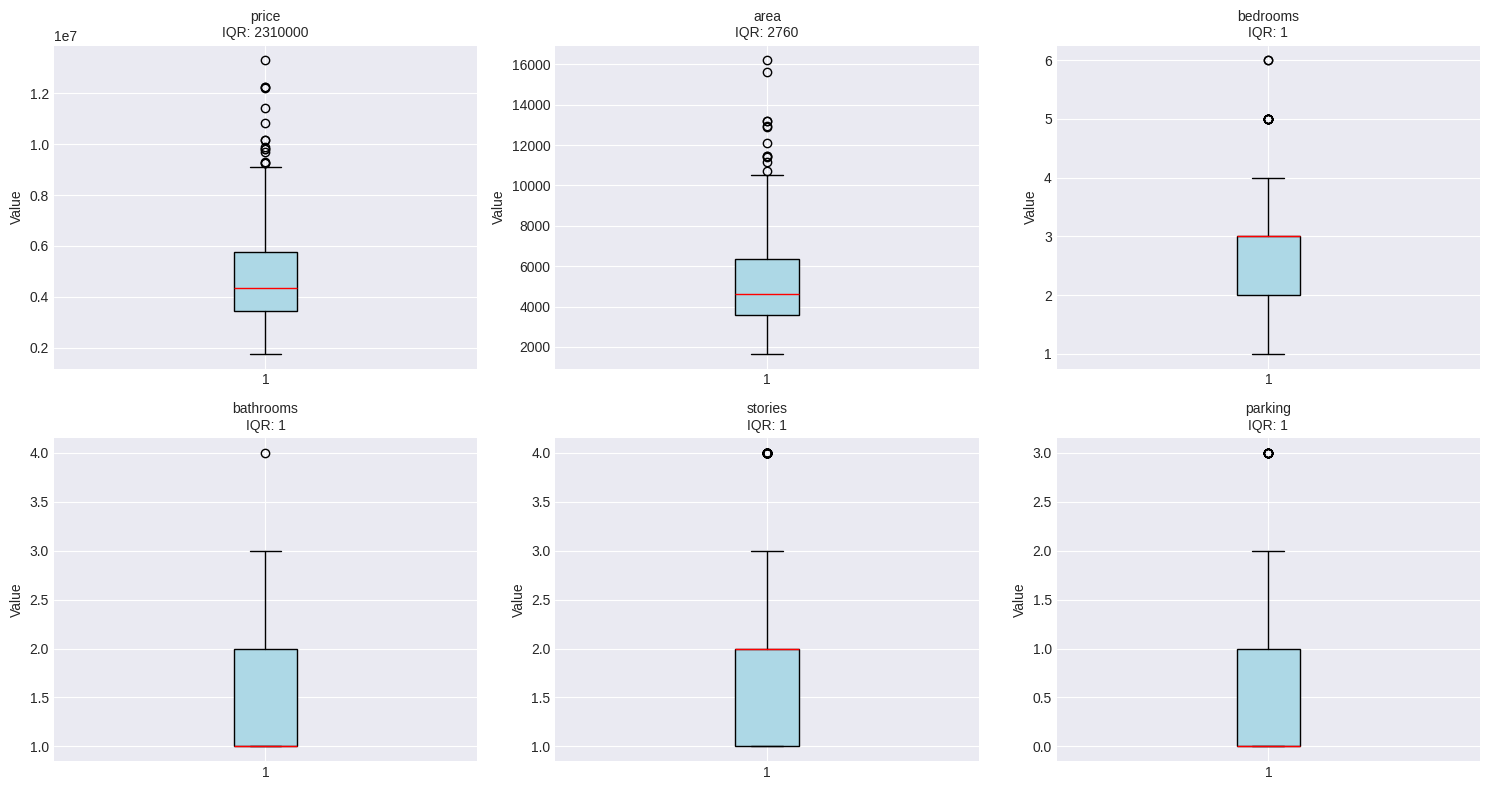


🔤 PART 2: ERRONEOUS DATA IN CATEGORICAL VARIABLES

🔤 Categorical variables to analyze (7):
  • mainroad
  • guestroom
  • basement
  • hotwaterheating
  • airconditioning
  • prefarea
  • furnishingstatus

📊 CHARTS OF CATEGORICAL VARIABLES:

📊 ANALYZING: mainroad
----------------------------------------
Unique values: 2
Null values: 0 (0.0%)

📈 DISTRIBUTION (Top 5 values):
  1. 'yes': 468 times (85.9%)
  2. 'no': 77 times (14.1%)

🔍 RARE CATEGORIES (<1% frequency):
  Number of rare categories: 0

⚠️  SUSPICIOUS VALUES:
  No obvious suspicious values found

💡 RECOMMENDATION:
  Acceptable distribution - keep as is

📊 ANALYZING: guestroom
----------------------------------------
Unique values: 2
Null values: 0 (0.0%)

📈 DISTRIBUTION (Top 5 values):
  1. 'no': 448 times (82.2%)
  2. 'yes': 97 times (17.8%)

🔍 RARE CATEGORIES (<1% frequency):
  Number of rare categories: 0

⚠️  SUSPICIOUS VALUES:
  No obvious suspicious values found

💡 RECOMMENDATION:
  Acceptable distribution - keep as is

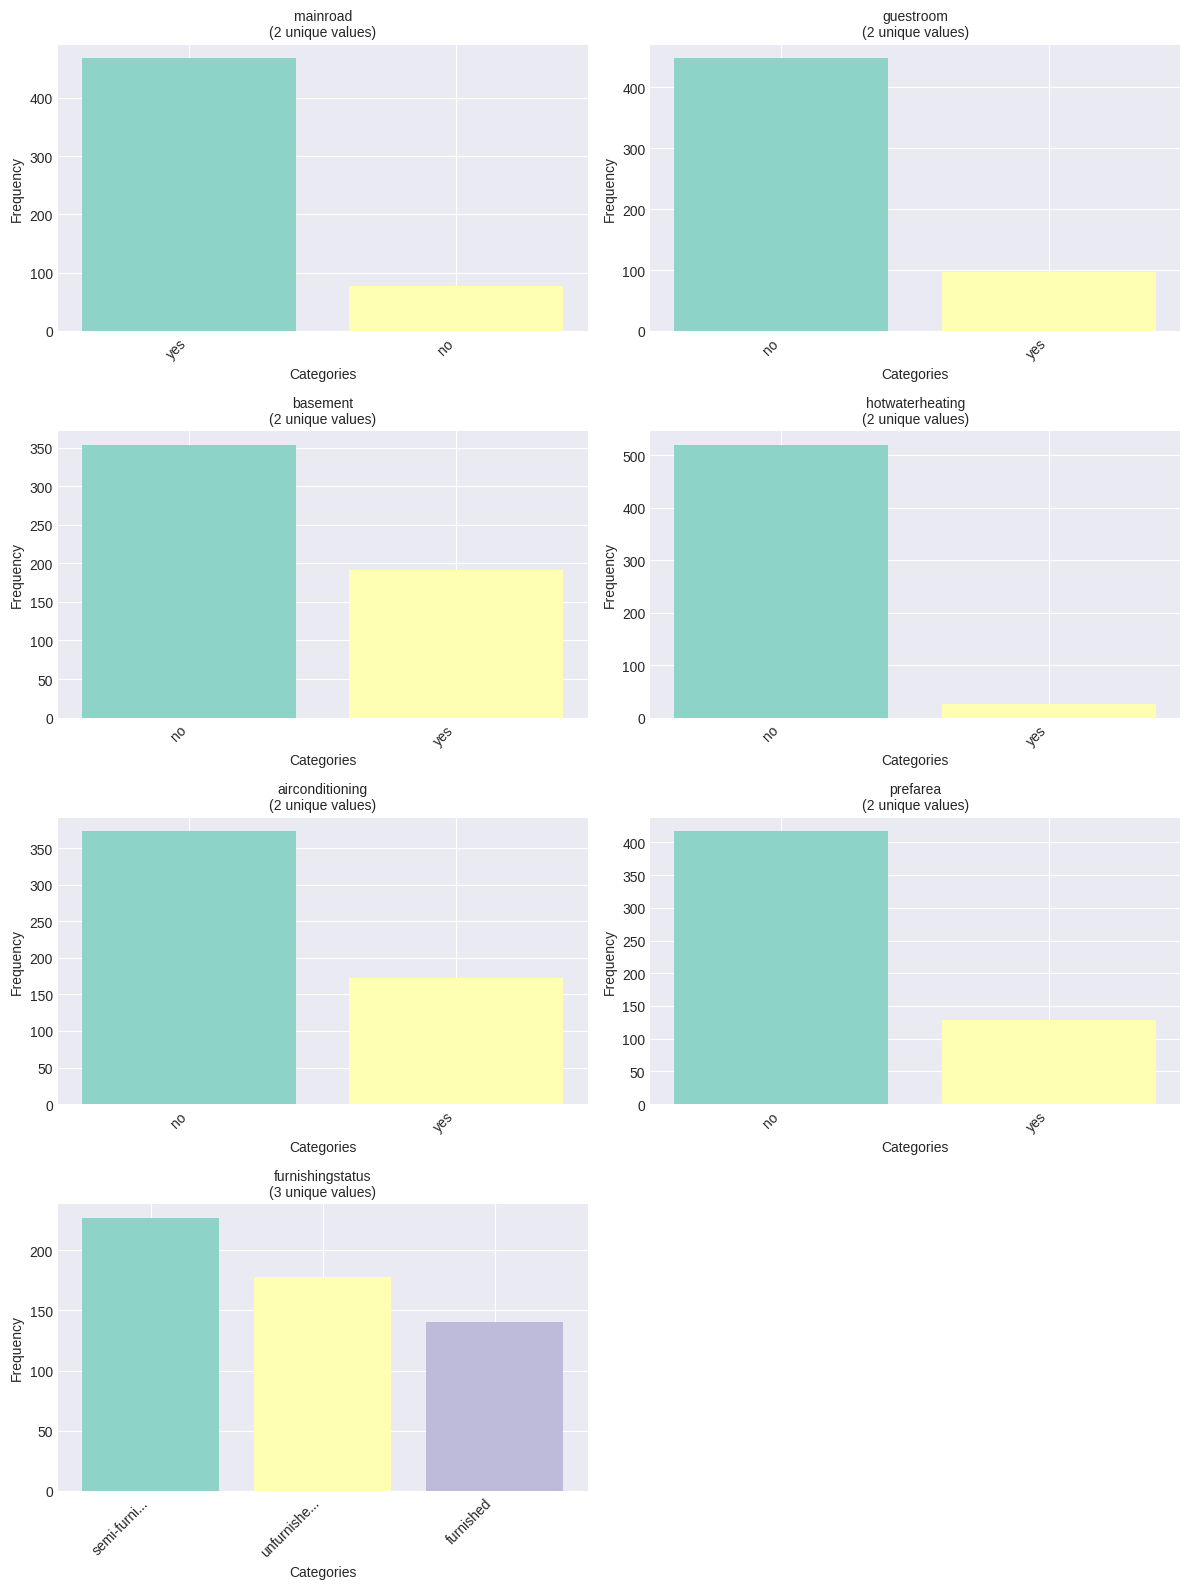

In [ ]:
# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("🔍 IDENTIFYING OUTLIERS AND ERRONEOUS DATA")
print("=" * 60)


# 1. SELECT IMPORTANT COLUMNS
print("\n📋 SELECTION OF IMPORTANT COLUMNS:")
print("-" * 40)

# Using all columns from the housing dataset as important columns
important_columns = data.columns.tolist()

# Filter only existing columns (redundant in this case but good practice)
existing_columns = [col for col in important_columns if col in data.columns]
print(f"Analyzing {len(existing_columns)} important columns:")
for i, col in enumerate(existing_columns, 1):
    print(f"  {i:2}. {col}")

# ============================================================================
# PART 1: OUTLIERS IN NUMERICAL VARIABLES (with Boxplots)
# ============================================================================
print("\n" + "=" * 60)
print("📊 PART 1: OUTLIERS IN NUMERICAL VARIABLES")
print("=" * 60)

# Separate numerical variables from our important ones
numerical_columns = []
for col in existing_columns:
    if data[col].dtype in ['int64', 'float64']:
        numerical_columns.append(col)

print(f"\n🔢 Numerical variables to analyze ({len(numerical_columns)}):")
for col in numerical_columns:
    print(f"  • {col}")

# Function to analyze each numerical variable
def analyze_numerical_variable(df, column):
    """
    Analyzes a numerical variable and detects outliers
    """
    print(f"\n📈 ANALYZING: {column}")
    print("-" * 40)

    # Basic statistics
    print(f"Type: {df[column].dtype}")
    print(f"Unique values: {df[column].nunique()}")
    print(f"Null values: {df[column].isnull().sum()} ({df[column].isnull().sum()/len(df)*100:.1f}%) ")

    # Descriptive statistics
    stats = df[column].describe()
    print(f"\n📊 Statistics:")
    print(f"  Minimum: {stats['min']:.2f}")
    print(f"  Maximum: {stats['max']:.2f}")
    print(f"  Mean: {stats['mean']:.2f}")
    print(f"  Median: {stats['50%']:.2f}")
    print(f"  Standard deviation: {stats['std']:.2f}")

    # Detect outliers using IQR method
    Q1 = stats['25%']
    Q3 = stats['75%']
    IQR = Q3 - Q1

    if IQR > 0:  # Avoid division by zero
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Count outliers
        outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
        num_outliers = len(outliers)
        percentage = (num_outliers / len(df)) * 100

        print(f"\n🔍 OUTLIERS (IQR method):")
        print(f"  Lower limit: {lower_limit:.2f}")
        print(f"  Upper limit: {upper_limit:.2f}")
        print(f"  Outliers found: {num_outliers} ({percentage:.1f}%)")

        # Recommendation
        print(f"\n💡 RECOMMENDATION:")
        if num_outliers == 0:
            print("  No outliers - keep data as is")
        elif percentage < 5:
            print("  Few outliers (<5%) - consider removing them")
        elif percentage < 15:
            print("  Some outliers (5-15%) - check if they are errors")
        else:
            print("  Many outliers (>15%) - probably natural distribution")

    return Q1, Q3, IQR

# Create boxplots to visually detect outliers
print("\n📦 CREATING BOXPLOTS TO VISUALLY DETECT OUTLIERS:")
num_numeric_cols = len(numerical_columns)
nrows = (num_numeric_cols + 2) // 3 # Calculate rows needed for 3 columns
fig, axes = plt.subplots(nrows, 3, figsize=(15, 4 * nrows))
axes = axes.flatten()

for idx, col in enumerate(numerical_columns):
    # Boxplot
    bp = axes[idx].boxplot(data[col].dropna(), patch_artist=True, vert=True)

    # Color
    bp['boxes'][0].set_facecolor('lightblue')
    bp['medians'][0].set_color('red')

    # Calculate outliers
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    # Add information
    axes[idx].set_title(f'{col}\nIQR: {IQR:.0f}', fontsize=10)
    axes[idx].set_ylabel('Value')

    # Analyze statistics
    analyze_numerical_variable(data, col)

# Hide empty axes
for idx in range(num_numeric_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# PART 2: ERRONEOUS DATA IN CATEGORICAL VARIABLES
# ============================================================================
print("\n" + "=" * 60)
print("🔤 PART 2: ERRONEOUS DATA IN CATEGORICAL VARIABLES")
print("=" * 60)

# Separate categorical variables from our important ones
categorical_columns = []
for col in existing_columns:
    if data[col].dtype == 'object':
        categorical_columns.append(col)

print(f"\n🔤 Categorical variables to analyze ({len(categorical_columns)}):")
for col in categorical_columns:
    print(f"  • {col}")

def analyze_categorical_variable(df, column):
    """
    Analyzes a categorical variable and detects problems
    """
    print(f"\n📊 ANALYZING: {column}")
    print("-" * 40)

    # Basic statistics
    unique_values = df[column].nunique()
    print(f"Unique values: {unique_values}")
    print(f"Null values: {df[column].isnull().sum()} ({df[column].isnull().sum()/len(df)*100:.1f}%)")

    # Value distribution
    count = df[column].value_counts()

    print(f"\n📈 DISTRIBUTION (Top 5 values):")
    for i, (value, frequency) in enumerate(count.head(5).items(), 1):
        percentage = (frequency / len(df)) * 100
        print(f"  {i}. '{value}': {frequency} times ({percentage:.1f}%)")

    # Detect rare categories (<1% frequency)
    rare_categories = count[count / len(df) < 0.01]
    num_rare_categories = len(rare_categories)

    print(f"\n🔍 RARE CATEGORIES (<1% frequency):")
    print(f"  Number of rare categories: {num_rare_categories}")

    if num_rare_categories > 0:
        print("  Examples of rare categories:")
        for value, frequency in rare_categories.head(3).items():
            print(f"    • '{value}' ({frequency} times)")

    # Detect suspicious values
    suspicious_values = []
    if df[column].dtype == 'object':
        for value in df[column].dropna().unique():
            if isinstance(value, str):
                value_str = str(value).lower()
                if ('unknown' in value_str or
                    'null' in value_str or
                    'nan' in value_str or
                    'none' in value_str or
                    'not' in value_str):
                    suspicious_values.append(value)

    print(f"\n⚠️  SUSPICIOUS VALUES:")
    if suspicious_values:
        print(f"  Found: {len(suspicious_values)}")
        for value in suspicious_values[:3]:  # Show only 3
            print(f"    • '{value}'")
    else:
        print("  No obvious suspicious values found")

    # Recommendation
    print(f"\n💡 RECOMMENDATION:")
    if unique_values > 20:
        print("  Too many unique values - consider grouping into 'Other'")
    elif num_rare_categories > 5:
        print("  Many rare categories - group the less frequent ones")
    else:
        print("  Acceptable distribution - keep as is")

# Create charts for categorical variables
print("\n📊 CHARTS OF CATEGORICAL VARIABLES:")
num_categorical_cols = len(categorical_columns)
nrows_cat = (num_categorical_cols + 1) // 2
fig, axes = plt.subplots(nrows_cat, 2, figsize=(12, 4 * nrows_cat))
axes = axes.flatten()

for idx, col in enumerate(categorical_columns):
    # Take top 10 categories to avoid saturating the chart
    top_categories = data[col].value_counts().head(10)

    # Bar chart
    bars = axes[idx].bar(range(len(top_categories)), top_categories.values,
                        color=plt.cm.Set3(range(len(top_categories))))

    # Configure
    axes[idx].set_title(f'{col}\n({data[col].nunique()} unique values)', fontsize=10)
    axes[idx].set_xlabel('Categories')
    axes[idx].set_ylabel('Frequency')

    # Rotate labels
    axes[idx].set_xticks(range(len(top_categories)))
    axes[idx].set_xticklabels([str(x)[:10] + '...' if len(str(x)) > 10 else str(x)
                              for x in top_categories.index], rotation=45, ha='right')

    # Analyze the variable
    analyze_categorical_variable(data, col)

# Hide empty axes
for idx in range(num_categorical_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
df_trash = data.copy()
df_trash.groupby('bedrooms')['price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

,mean,count
bedrooms,,
5,5.819800e+06,10
4,5.729758e+06,95
3,4.954598e+06,300
6,4.791500e+06,2
2,3.632022e+06,136
1,2.712500e+06,2


In [ ]:
df_trash.groupby('area')['price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

,mean,count
area,,
7420,12355000.0,2
8960,12250000.0,1
9960,12250000.0,1
7500,11532500.0,2
16200,10150000.0,1
...,...,...
2400,1933575.0,2
1700,1890000.0,1
3649,1890000.0,1


In [ ]:
df_trash.groupby('stories')['price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

,mean,count
stories,,
4,7.208450e+06,41
3,5.685436e+06,39
2,4.764074e+06,238
1,4.170659e+06,227


In [ ]:
df_trash.groupby('area')['price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

,mean,count
area,,
7420,12355000.0,2
8960,12250000.0,1
9960,12250000.0,1
7500,11532500.0,2
16200,10150000.0,1
...,...,...
2400,1933575.0,2
1700,1890000.0,1
3649,1890000.0,1


**1.8 Identification of erroneous data**


In [ ]:
# Check for inconsistencies: How many unique values are lost when normalizing to lowercase?
print("🔍 Checking for Case-Sensitivity Inconsistencies in Categorical Columns")
print("-" * 70)

categorical_cols = data.select_dtypes(include=['object']).columns

case_inconsistencies = {}
for col in categorical_cols:
    initial_unique_count = data[col].nunique()
    lowercase_unique_count = data[col].astype(str).str.lower().nunique()
    if initial_unique_count - lowercase_unique_count > 0:
        case_inconsistencies[col] = initial_unique_count - lowercase_unique_count

if case_inconsistencies:
    print("Found columns with case-sensitivity inconsistencies (values lost after lowercase conversion):")
    for col, lost_values in case_inconsistencies.items():
        print(f"  - '{col}': {lost_values} unique value(s) would be lost (due to different casing)")
else:
    print("No case-sensitivity inconsistencies found in categorical columns. All values are consistently cased or have no duplicates with different casing.")

print("\n" + "-" * 70)

# For this housing dataset, binary columns like 'mainroad', 'guestroom', etc., have already been checked
# in the comprehensive categorical analysis (Section 1.6). They were found to contain only 'yes'/'no'
# and no other values, so no further specific binary checks are needed here.

# The outlier detection using the IQR method in Section 1.6 already covered extreme numerical values
# for 'price', 'area', 'bedrooms', 'bathrooms', 'stories', and 'parking'. This includes identifying
# values that are unusually high or low based on the data distribution. Therefore, explicit checks
# for 'unrealistic' numerical ranges are largely redundant here.

# Quick check for suspicious terms in critical categorical columns
print("\n🔍 Checking for common 'Noisy' or Suspicious Terms in Categorical Columns")
print("-" * 70)

noisy_terms = ['unknown', 'unspecified', 'not set', 'nan', 'null', 'na', 'n/a']

found_noisy_data = False
for col in categorical_cols:
    # Convert column to string type to handle potential mixed types and then to lowercase
    mask = data[col].astype(str).str.lower().isin(noisy_terms)
    num_noisy = mask.sum()

    if num_noisy > 0:
        found_noisy_data = True
        percentage_noisy = (num_noisy / len(data)) * 100
        print(f"  - '{col}': {num_noisy} value(s) match noisy terms ({percentage_noisy:.2f}%)")
        print(f"    Examples: {data.loc[mask, col].unique()[:5].tolist()}") # Show first 5 unique noisy values

if not found_noisy_data:
    print("No common noisy or suspicious terms found in categorical columns.")

print("\n" + "-" * 70)

🔍 Checking for Case-Sensitivity Inconsistencies in Categorical Columns
----------------------------------------------------------------------
No case-sensitivity inconsistencies found in categorical columns. All values are consistently cased or have no duplicates with different casing.

----------------------------------------------------------------------

🔍 Checking for common 'Noisy' or Suspicious Terms in Categorical Columns
----------------------------------------------------------------------
No common noisy or suspicious terms found in categorical columns.

----------------------------------------------------------------------


**1.9. Correlation of variables with the target**


--- Top Variables with absolute correlation > 0.05 with 'price' (Ranking) ---


,price
area,0.535997
bathrooms,0.517545
airconditioning,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea,0.329777
furnishingstatus,-0.304721
mainroad,0.296898
guestroom,0.255517


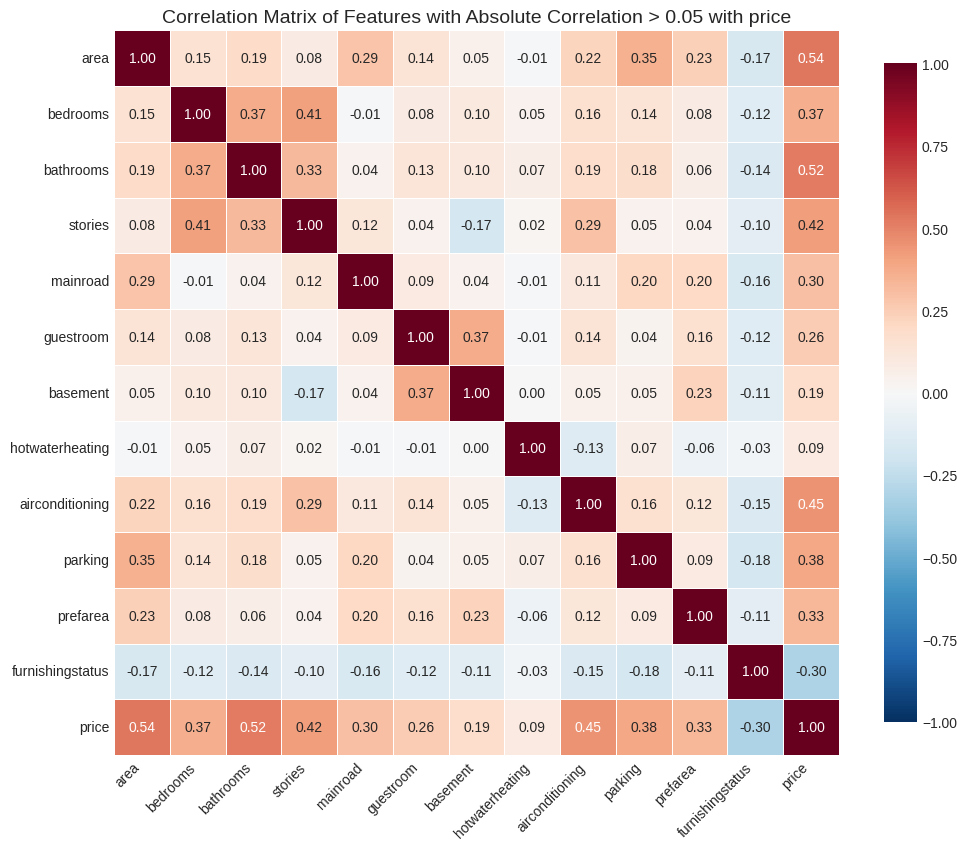

In [ ]:
# Define the target variable for the housing dataset
target_variable = 'price'

# Correlation threshold (adjustable based on desired sensitivity)
correlation_threshold = 0.05

# Create a copy of the dataframe for analysis to avoid modifying the original 'data'
df_analysis = data.copy()

# Identify numerical and categorical (object/category) columns
numerical_cols = df_analysis.select_dtypes(include=['number']).columns.tolist()
categorical_obj_cols = df_analysis.select_dtypes(include=['object', 'category']).columns.tolist()

# Apply Label Encoding to categorical columns to convert them to numerical format
# This is necessary for calculating correlations with these features.
le = LabelEncoder()
for col in categorical_obj_cols:
    df_analysis[col] = df_analysis[col].astype(str) # Ensure all categorical values are strings
    df_analysis[col] = le.fit_transform(df_analysis[col])

# Calculate correlations of all features with the target variable
# Ensure the target variable is included in the dataframe before correlation calculation
if target_variable not in df_analysis.columns:
    print(f"Warning: Target variable '{target_variable}' not found in df_analysis.")
    # If the target was removed, we might need to re-add it or adjust.

correlations_with_target = df_analysis.corr()[target_variable]

# Filter for important features (absolute correlation greater than the threshold)
# Exclude the target variable itself from the list of important features
important_features = correlations_with_target[abs(correlations_with_target) > correlation_threshold].drop(target_variable, errors='ignore')

print(f"--- Top Variables with absolute correlation > {correlation_threshold} with '{target_variable}' (Ranking) ---")
display(important_features.sort_values(key=abs, ascending=False))

# Prepare columns for plotting the correlation matrix
# Include the important features and the target variable
cols_to_plot = important_features.index.tolist() + [target_variable]
correlation_matrix_plot = df_analysis[cols_to_plot].corr()

# Dynamically adjust figure size based on the number of variables to plot
num_vars = len(cols_to_plot)
fig_width = max(8, num_vars * 0.8) # Adjusted for better visualization
fig_height = max(6, num_vars * 0.7) # Adjusted for better visualization

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(correlation_matrix_plot,
            annot=True, # Show the correlation values on the heatmap
            fmt=".2f", # Format annotations to two decimal places
            cmap='RdBu_r', # Colormap, 'RdBu_r' shows positive/negative correlations clearly
            center=0, # Center the colormap at 0
            vmin=-1, vmax=1, # Set the color range from -1 to 1
            square=True, # Make cells square
            linewidths=.5, # Add lines between cells
            cbar_kws={"shrink": .8}) # Shrink color bar for better fit

plt.title(f'Correlation Matrix of Features with Absolute Correlation > {correlation_threshold} with {target_variable}', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
corr=data.corr(numeric_only=True)
corr
corr.style.background_gradient(cmap='coolwarm')

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


### 1.10 Advanced Association Analysis with Target Variable (Adapted)

This section adapts your previous association analysis code to the current housing dataset. Given that our target variable, 'price', is continuous, the methods used for association analysis will be adjusted:

*   For **Categorical Features vs. Continuous Target ('price')**: We will calculate **Eta-squared**. Eta-squared is a measure of effect size that quantifies the proportion of variance in a dependent variable (price) explained by an independent categorical variable.
*   For **Numerical Features vs. Continuous Target ('price')**: We will use **Pearson Correlation**, which measures the linear relationship between two continuous variables.

Calculating Eta-squared for categorical features...
Calculating Pearson Correlation for numerical features...

--- Top Features by Association Score (Ranking) ---


,feature,score,type
7,area,0.535997,Pearson Corr.
9,bathrooms,0.517545,Pearson Corr.
10,stories,0.420712,Pearson Corr.
11,parking,0.384394,Pearson Corr.
8,bedrooms,0.366494,Pearson Corr.
4,airconditioning,0.205167,Eta-squared
5,prefarea,0.108753,Eta-squared
6,furnishingstatus,0.094469,Eta-squared
0,mainroad,0.088149,Eta-squared
1,guestroom,0.065289,Eta-squared


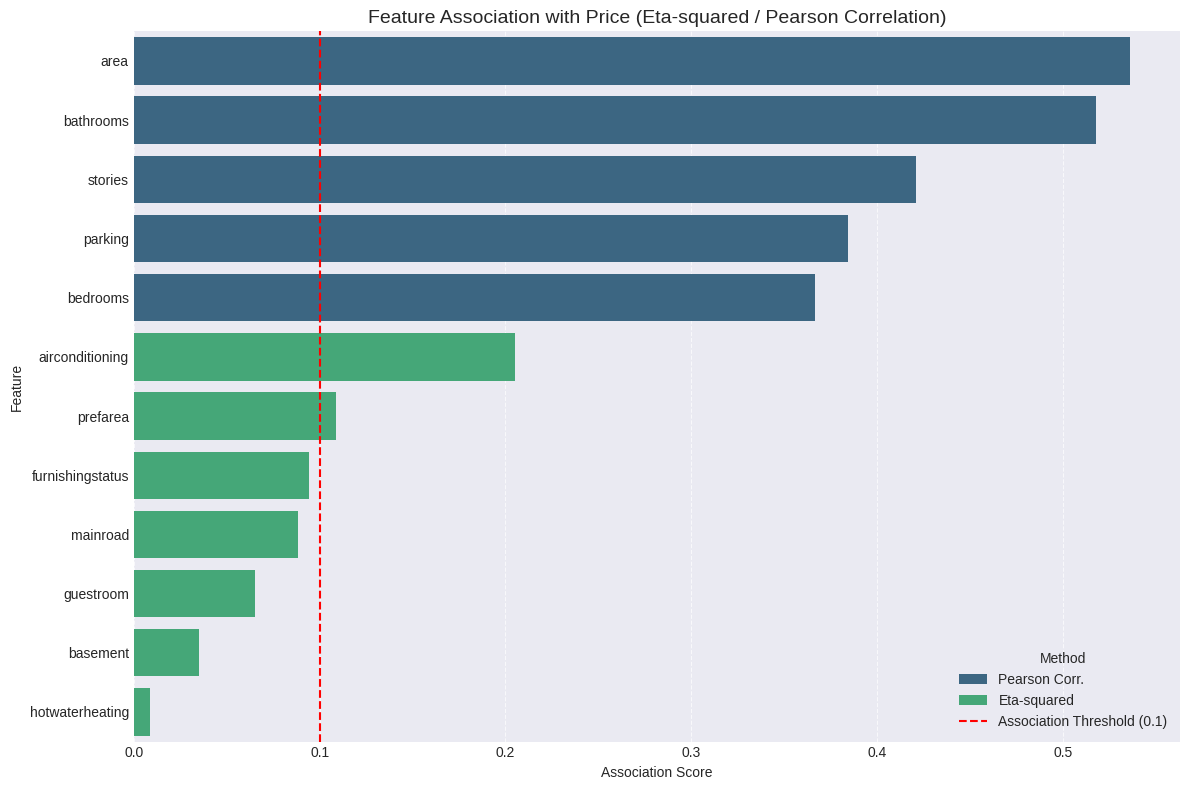

In [ ]:
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.formula.api import ols

def analyze_advanced_association(df, target_col='price'):
    """
    Calculates the association of features with a continuous target variable,
    using Eta-squared for categorical features and Pearson correlation for numerical features.
    """
    df_analysis = df.copy()
    results = []

    # Identify categorical and numerical columns
    # Exclude the target column from being processed as a feature itself
    categorical_features = df_analysis.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_features = df_analysis.select_dtypes(include=['number']).columns.tolist()
    if target_col in numerical_features:
        numerical_features.remove(target_col)

    # 1. Calculate Eta-squared for Categorical Features vs. Continuous Target
    print("Calculating Eta-squared for categorical features...")
    for col in categorical_features:
        # Drop rows with NaN in either the feature or target for this calculation
        temp_df = df_analysis[[col, target_col]].dropna()

        if len(temp_df) > 0 and temp_df[col].nunique() > 1: # Ensure enough data and variability
            # Calculate Sum of Squares Total (SST)
            ss_total = ((temp_df[target_col] - temp_df[target_col].mean()) ** 2).sum()

            # Calculate Sum of Squares Between (SSB)
            # SSB = sum(n_i * (mean_i - grand_mean)^2)
            grouped_means = temp_df.groupby(col, observed=False)[target_col].mean()
            group_sizes = temp_df.groupby(col, observed=False).size()
            grand_mean = temp_df[target_col].mean()

            ss_between = (group_sizes * ((grouped_means - grand_mean) ** 2)).sum()

            eta_squared = ss_between / ss_total if ss_total > 0 else 0
            results.append({'feature': col, 'score': eta_squared, 'type': 'Eta-squared'})
        else:
            results.append({'feature': col, 'score': 0.0, 'type': 'Eta-squared'}) # No variability or data for calculation

    # 2. Calculate Pearson Correlation for Numerical Features vs. Continuous Target
    print("Calculating Pearson Correlation for numerical features...")
    for col in numerical_features:
        # Handle potential NaN values by imputing with median for the correlation test
        # This mimics the original point-biserial approach's quick imputation.
        series = df_analysis[col].fillna(df_analysis[col].median())
        if series.nunique() > 1: # Ensure variability for correlation
            # Pearsonr returns (correlation_coefficient, p_value)
            corr_coeff, _ = pearsonr(series, df_analysis[target_col])
            results.append({'feature': col, 'score': abs(corr_coeff), 'type': 'Pearson Corr.'})
        else:
            results.append({'feature': col, 'score': 0.0, 'type': 'Pearson Corr.'}) # No variability for calculation

    # 3. Consolidate results
    report = pd.DataFrame(results).sort_values('score', ascending=False)
    return report

# Execute the analysis
final_report = analyze_advanced_association(data, target_col='price')

print("\n--- Top Features by Association Score (Ranking) ---")
display(final_report.head(15))

# Plotting the results
plt.figure(figsize=(12, 8))
sns.barplot(data=final_report.head(15), x='score', y='feature', hue='type', palette='viridis', dodge=False)

# Define an association threshold for visualization. This is subjective and can be adjusted.
association_threshold = 0.1 # Example threshold, can be adjusted
plt.axvline(association_threshold, color='red', linestyle='--', label=f'Association Threshold ({association_threshold})')

plt.title('Feature Association with Price (Eta-squared / Pearson Correlation)', fontsize=14)
plt.xlabel('Association Score')
plt.ylabel('Feature')
plt.legend(title='Method')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# For the moment, we have identified these relevant variables that explain the behavior of the price, in order of relevance:
# area, bathrooms, stories, parking, bedrooms, and air conditioning.

**10. Correlation of variables with the class (univariate)**


This section provides a univariate visualization of the relationship between each feature and the target variable ('price'). For each feature, it calculates the average 'price' for different groups/categories and plots them, highlighting the overall global average price for context. This helps to quickly identify features that show a clear pattern or trend with the target.

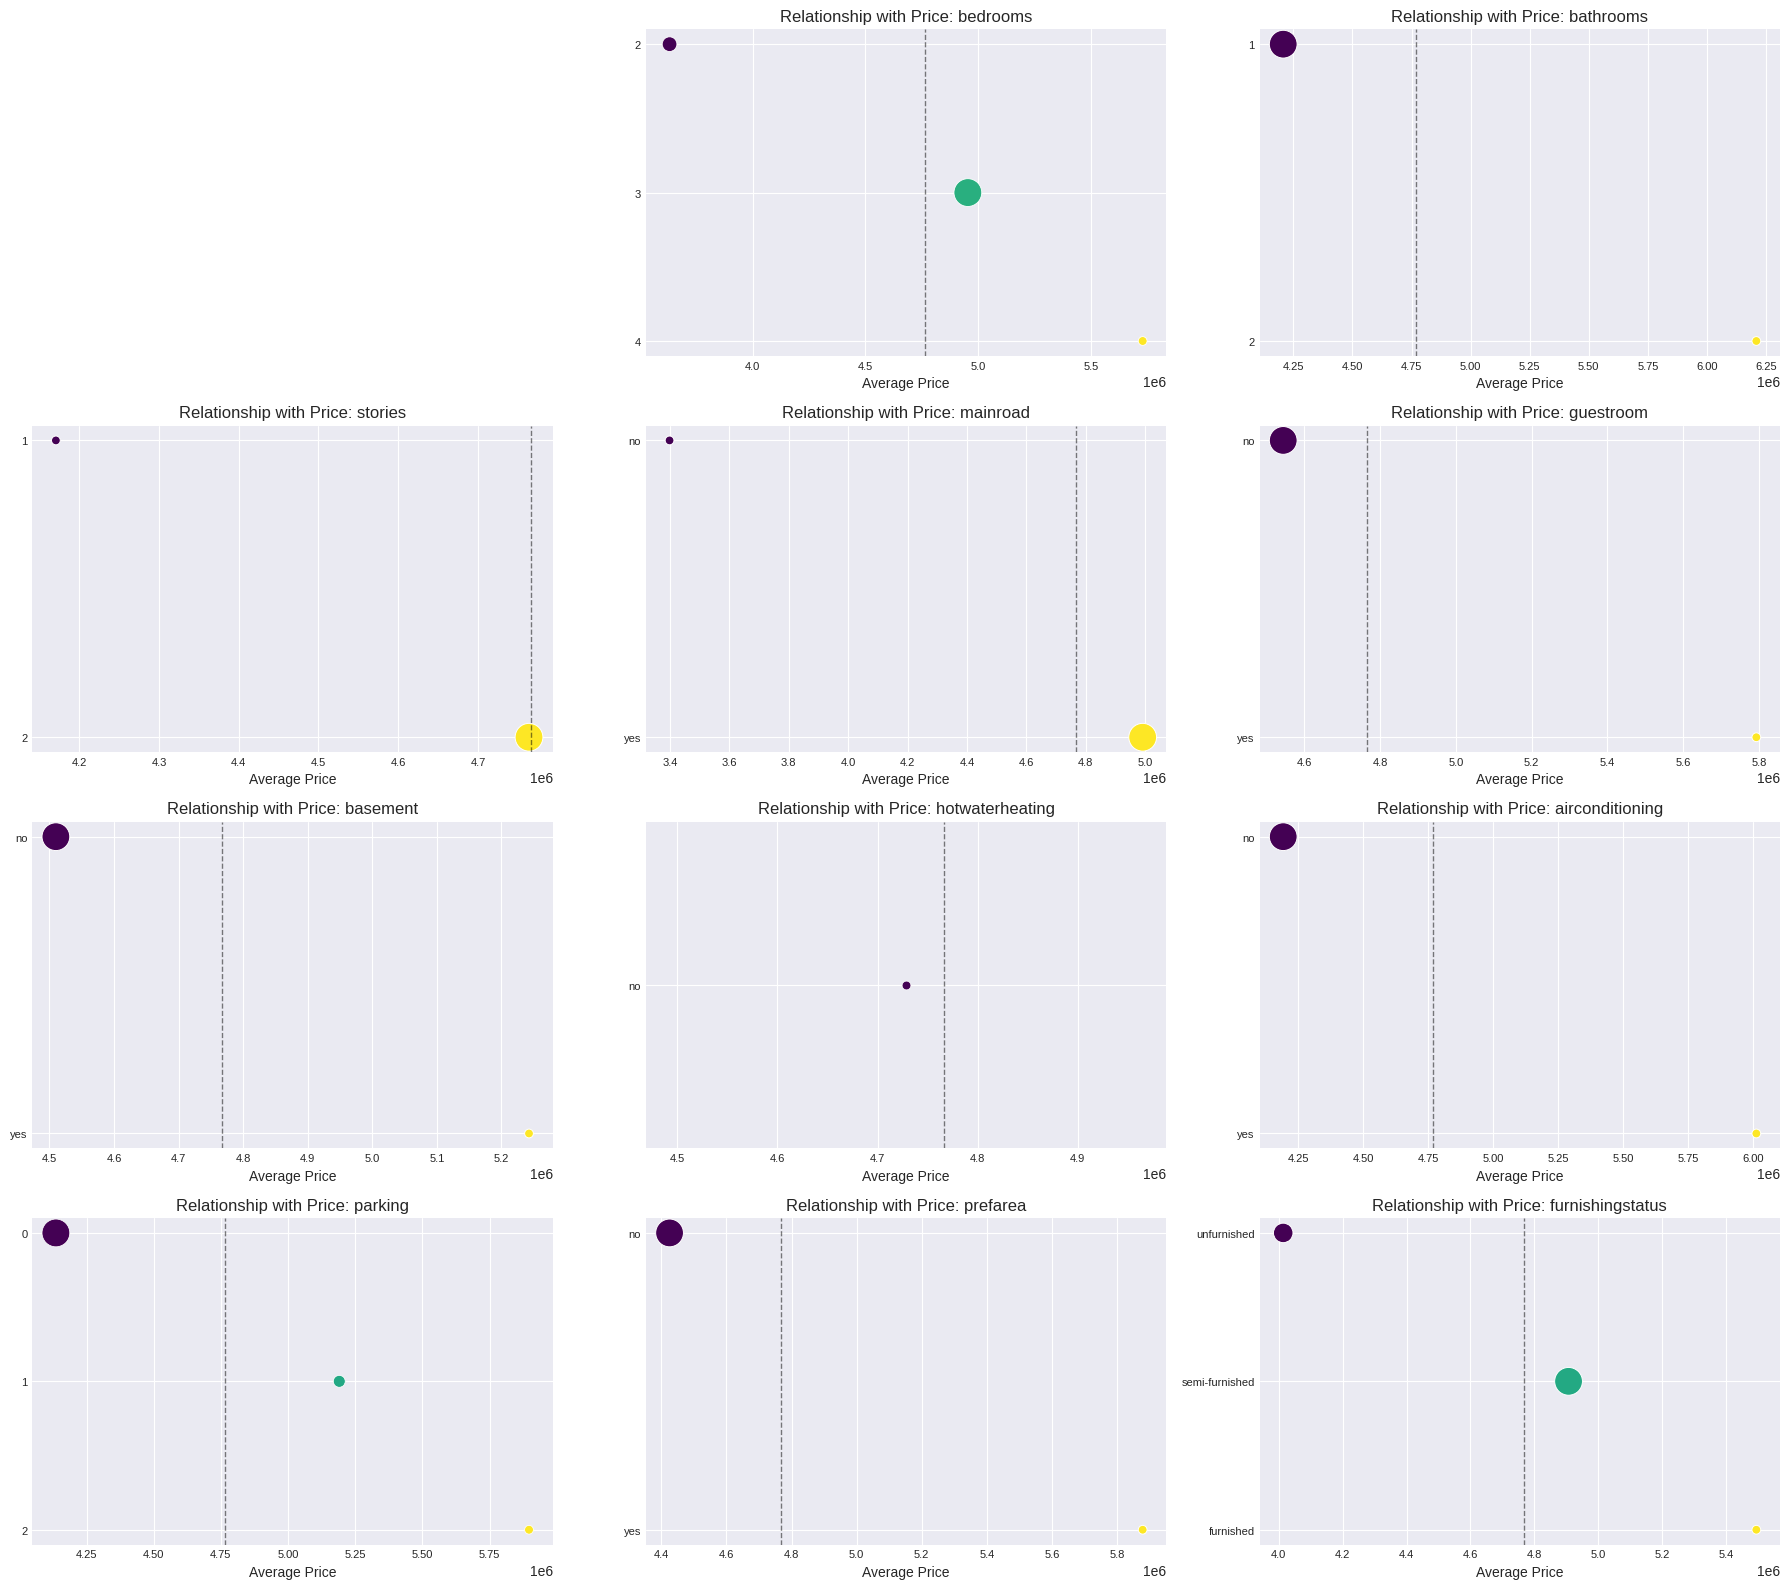

In [ ]:
def visualize_univariate_feature_target_relationship(df, target_col='price', min_observations=100, top_n_groups=15):
    """
    Visualizes the univariate relationship between features and a continuous target variable.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_col (str): The name of the continuous target column.
        min_observations (int): Minimum number of observations a group must have to be included in the plot.
        top_n_groups (int): The number of top groups (by count) to display for each feature.
    """

    # Initial filter for irrelevant columns (excluding the target itself)
    features = [c for c in df.columns if c != target_col]

    global_average_target = df[target_col].mean()

    num_cols = 3
    num_rows = (len(features) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4 * num_rows))
    axes = axes.flatten()

    for i, feature_col in enumerate(features):
        # observed=False prevents FutureWarning for categorical columns in pandas >= 1.0
        # and treats 'category' dtype as groups, not as ordered intervals.
        group_statistics = df.groupby(feature_col, observed=False)[target_col].agg(['mean', 'count'])

        # Filter groups by minimum observations and select top_n_groups by count
        group_statistics = group_statistics[group_statistics['count'] >= min_observations].nlargest(top_n_groups, 'count').sort_values('mean')

        if not group_statistics.empty:
            sns.scatterplot(
                ax=axes[i], x=group_statistics['mean'], y=group_statistics.index.astype(str),
                size=group_statistics['count'], sizes=(40, 400), hue=group_statistics['mean'],
                palette='viridis', legend=False # Viridis palette for continuous 'mean'
            )
            axes[i].axvline(global_average_target, color='black', linestyle='--', lw=1, alpha=0.5)
            axes[i].set(title=f"Relationship with {target_col.capitalize()}: {feature_col}",
                        xlabel=f"Average {target_col.capitalize()}", ylabel="")
            axes[i].tick_params(labelsize=8)
        else:
            axes[i].axis('off') # Hide axis if no data to plot

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Execute the visualization function with the housing data and 'price' as the target
visualize_univariate_feature_target_relationship(data, target_col='price', min_observations=50)

**11. Graphical visualization of distributions**

✓ Numerical: histograms, box plots, violin plots, decile views, etc.

✓ Categorical: bar charts, direct counts, etc.

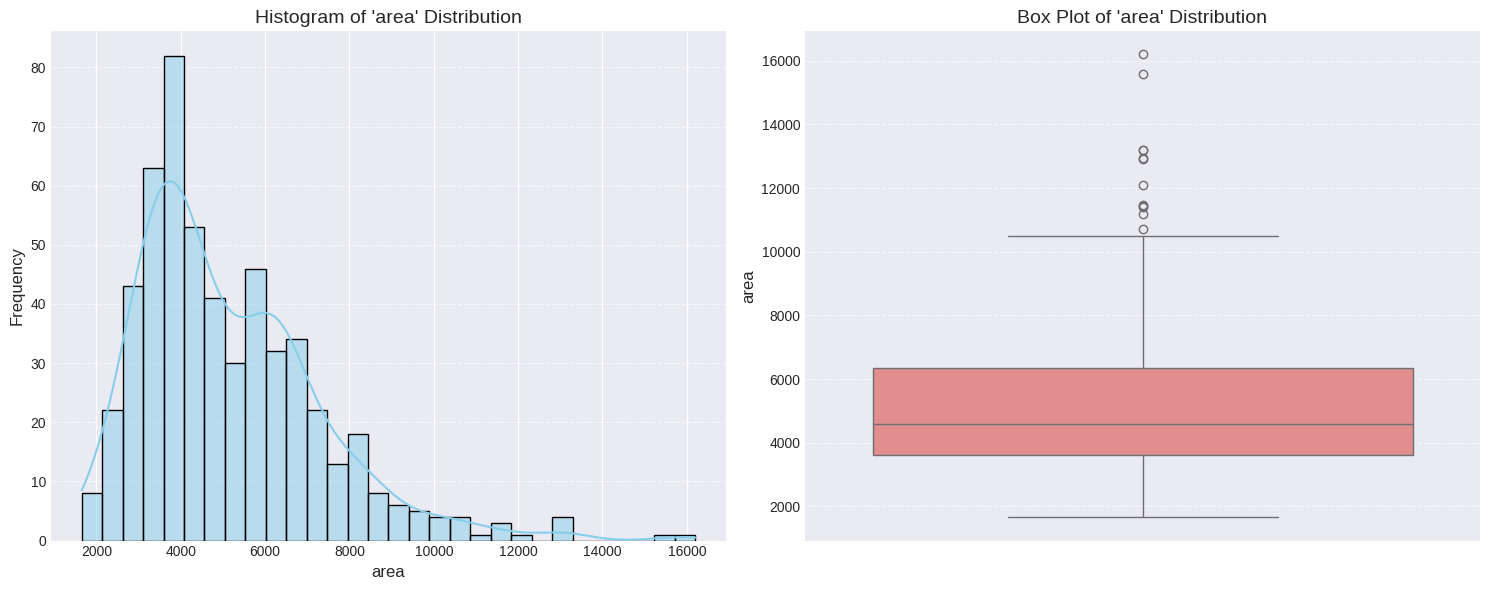

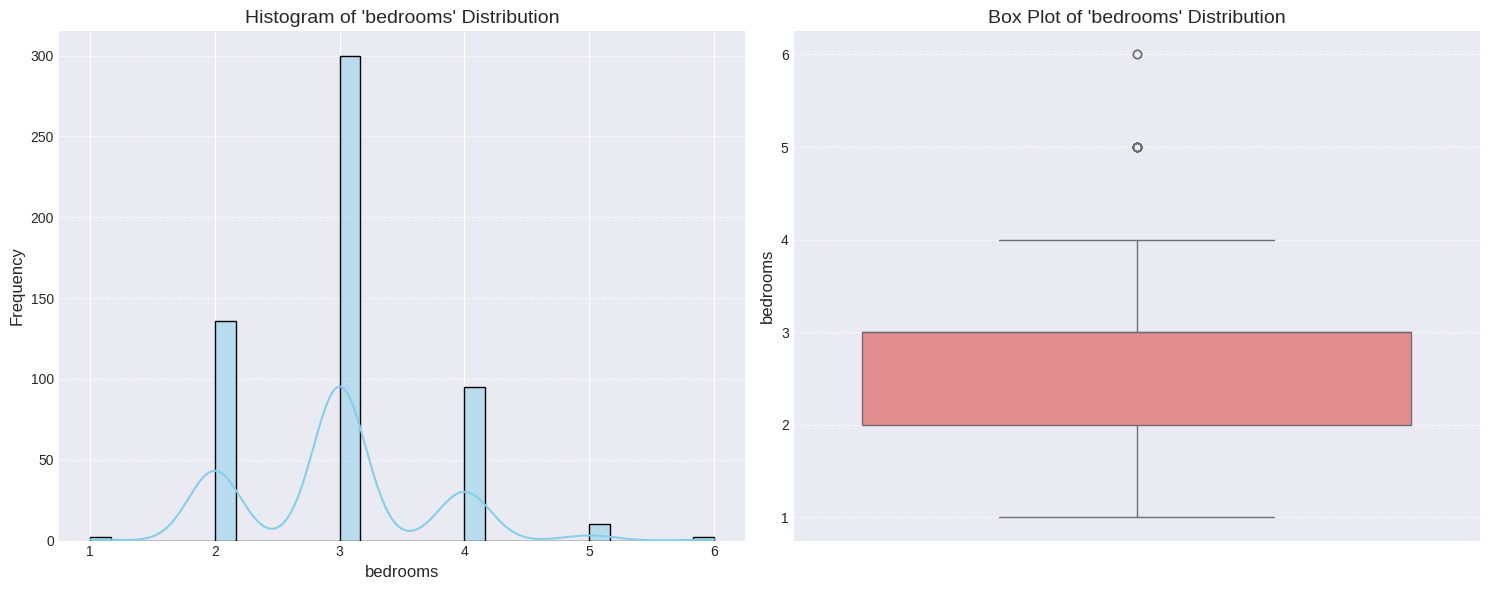

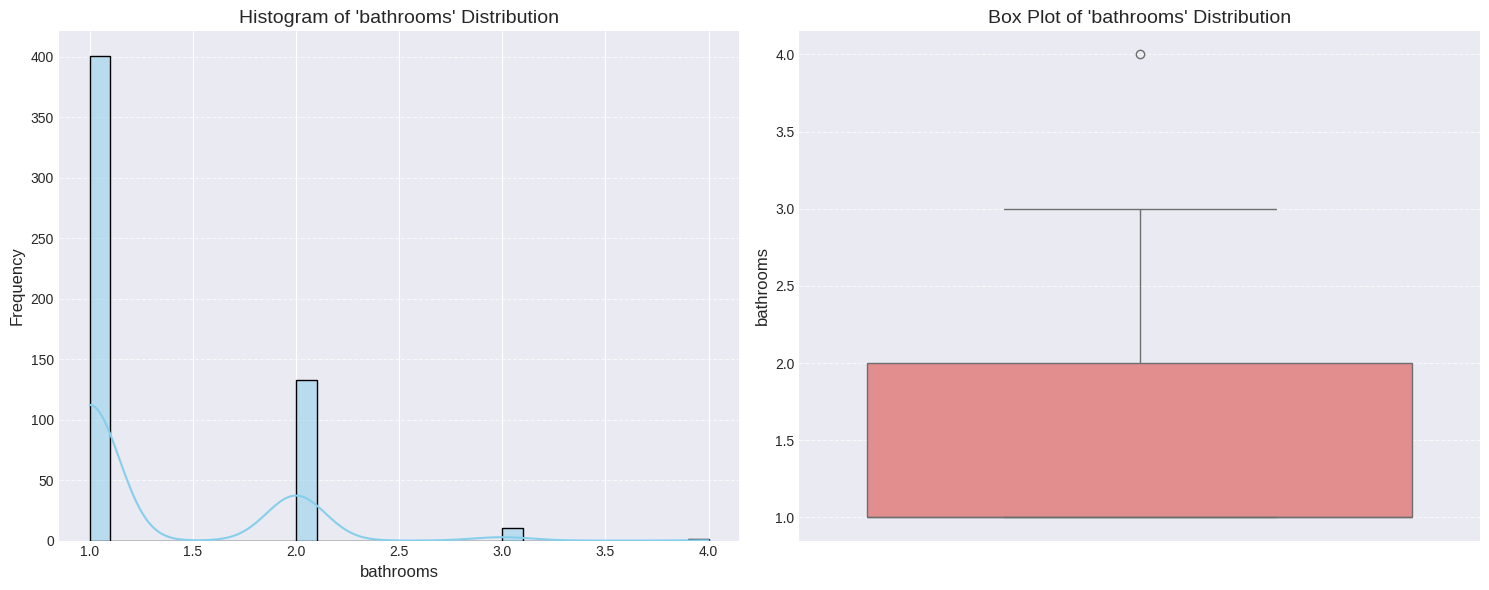

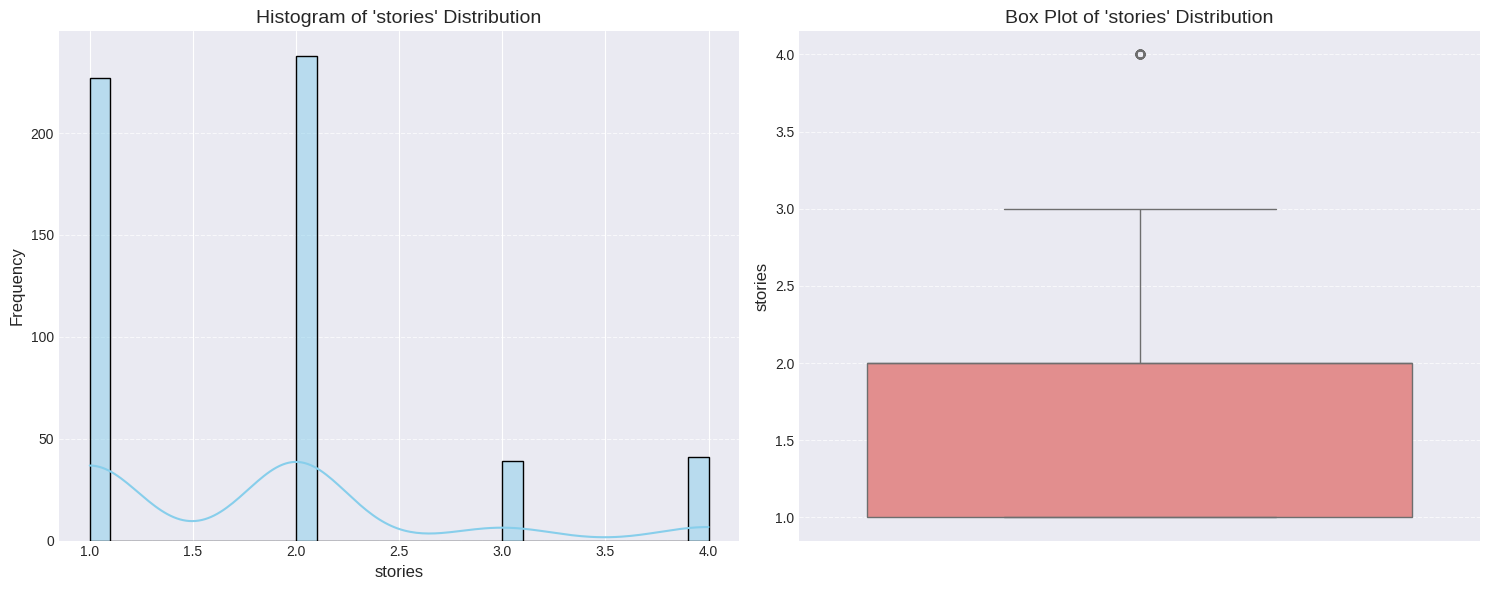

/tmp/ipykernel_579/2367539263.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
/tmp/ipykernel_579/2367539263.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)


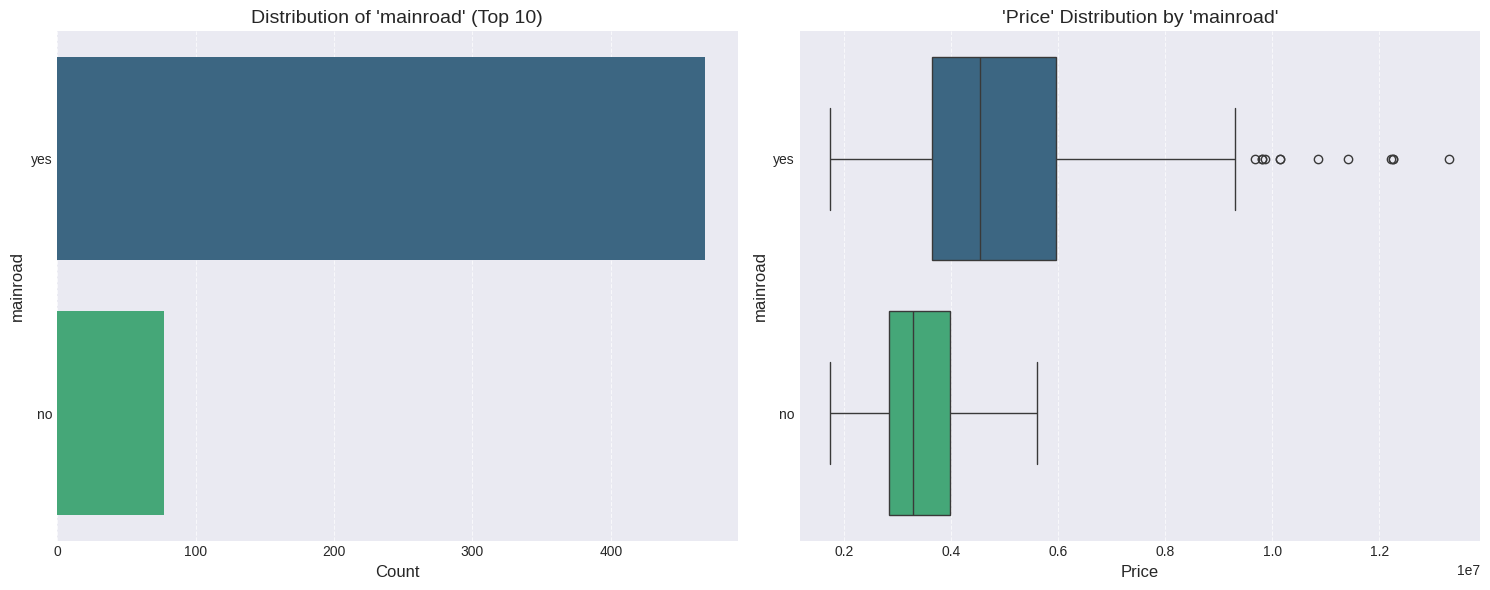

/tmp/ipykernel_579/2367539263.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
/tmp/ipykernel_579/2367539263.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)


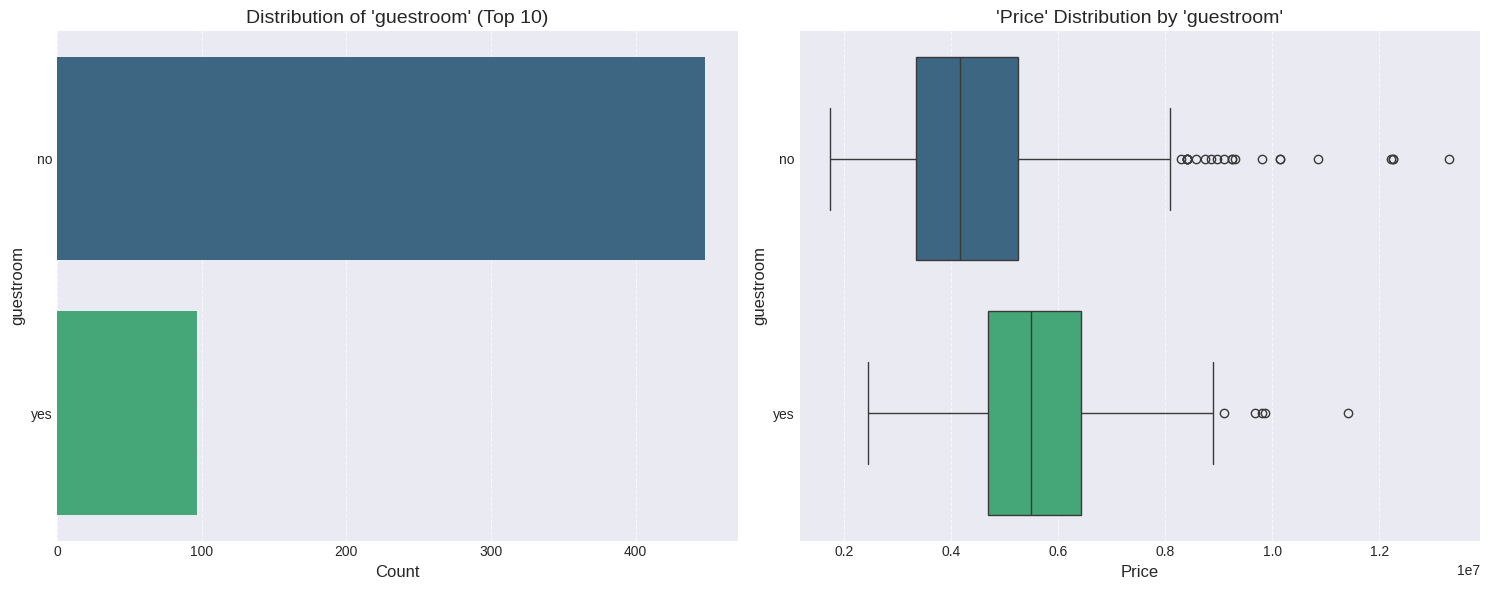

/tmp/ipykernel_579/2367539263.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
/tmp/ipykernel_579/2367539263.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)


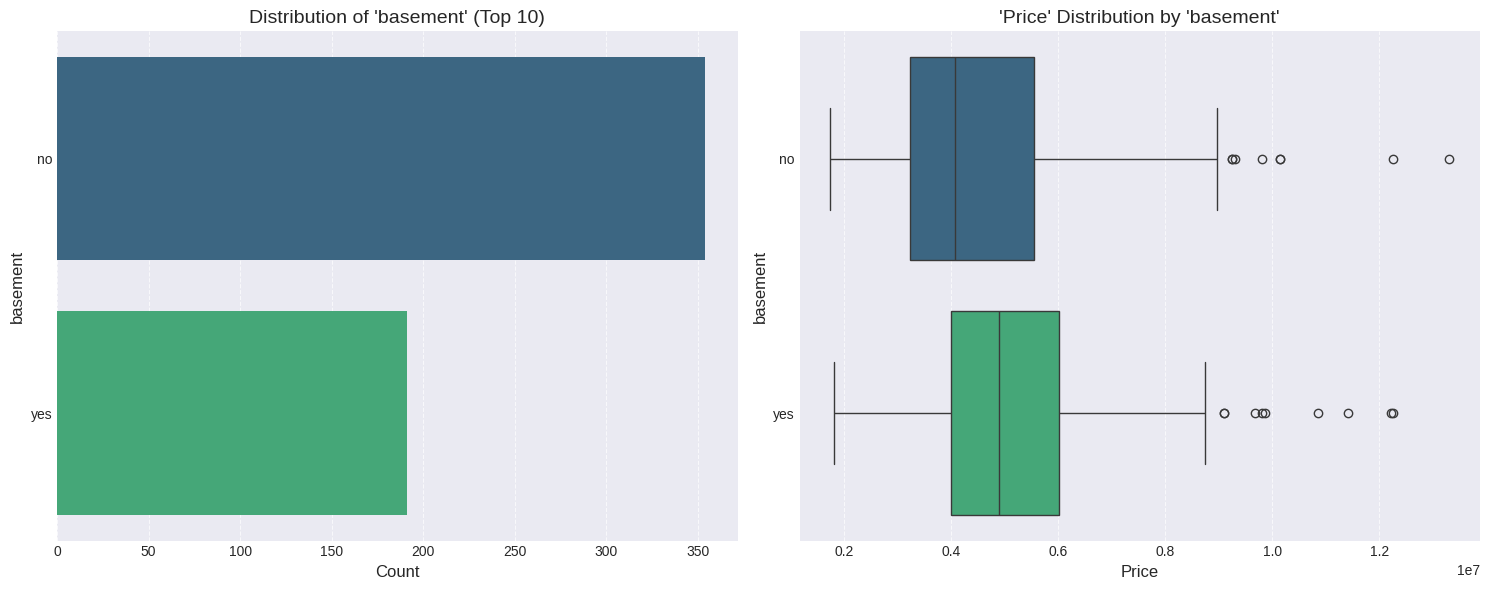

/tmp/ipykernel_579/2367539263.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
/tmp/ipykernel_579/2367539263.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)


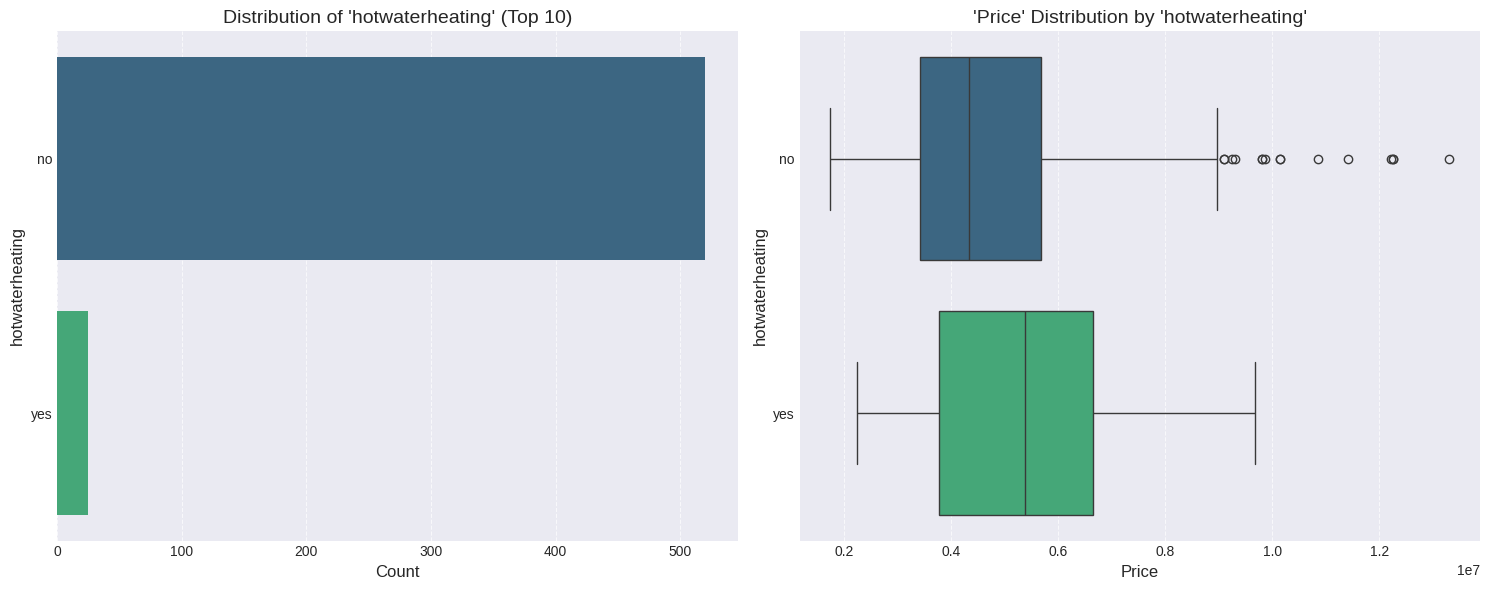

/tmp/ipykernel_579/2367539263.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
/tmp/ipykernel_579/2367539263.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)


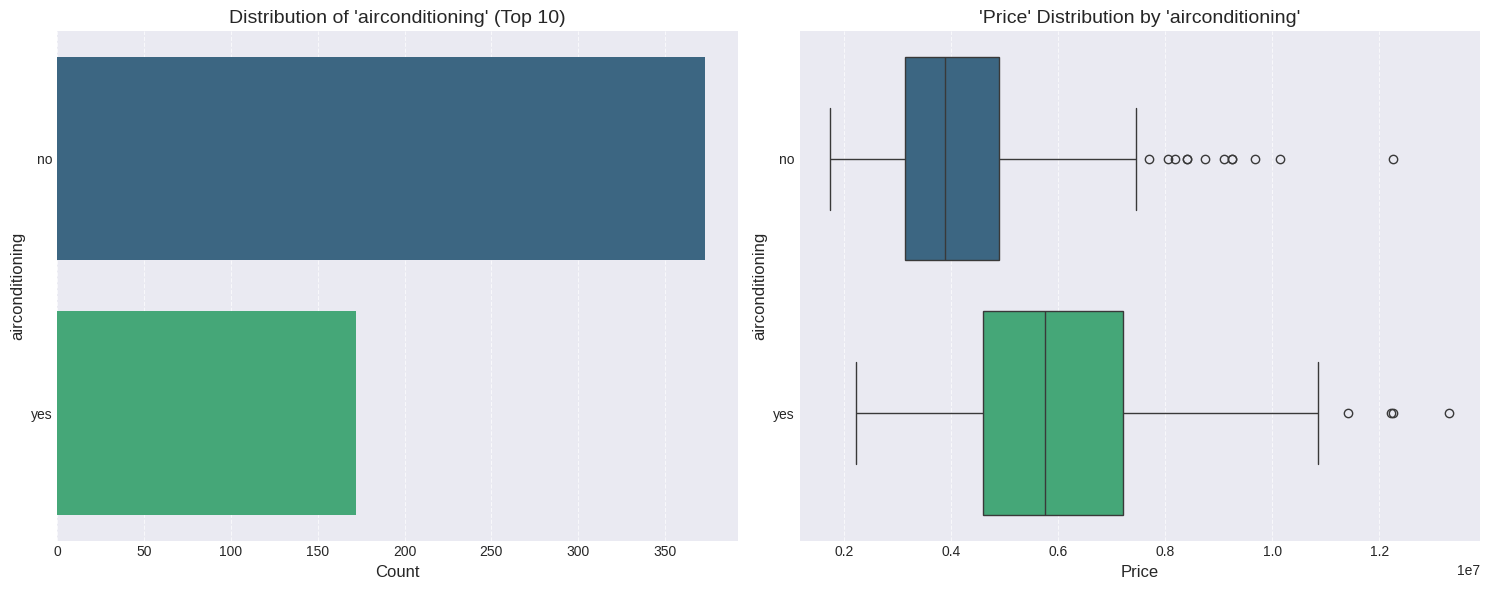

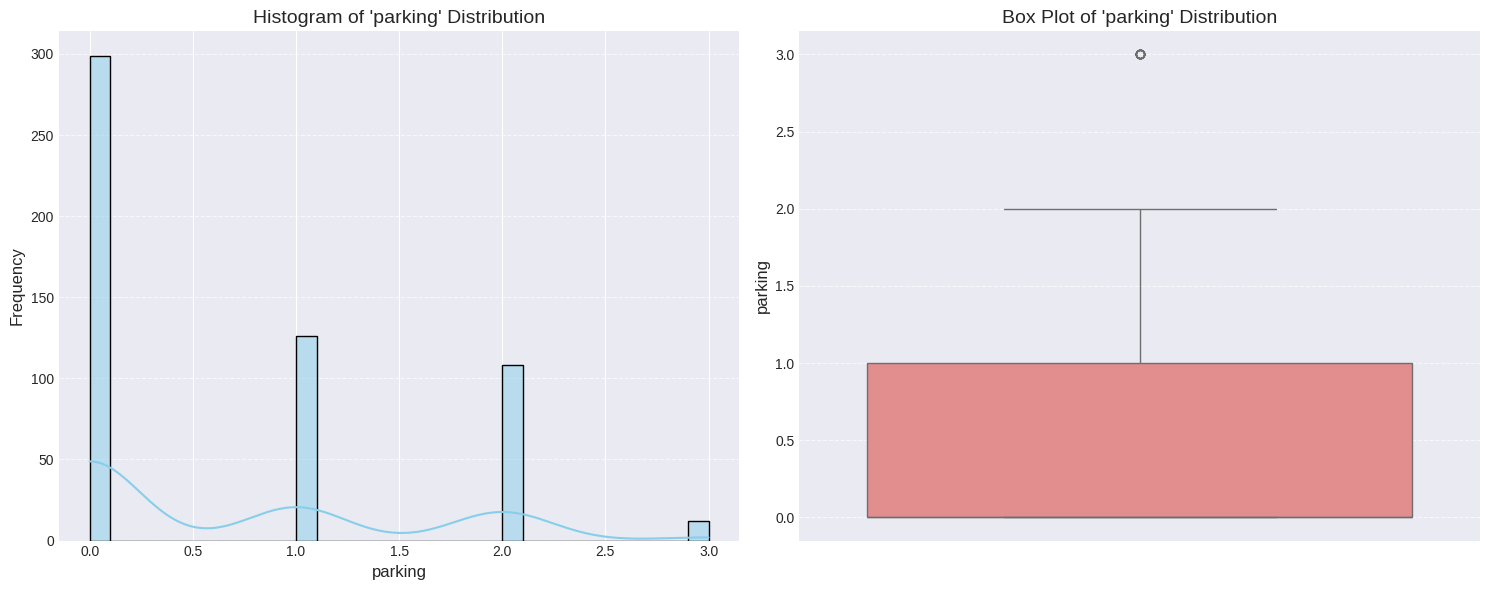

/tmp/ipykernel_579/2367539263.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
/tmp/ipykernel_579/2367539263.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)


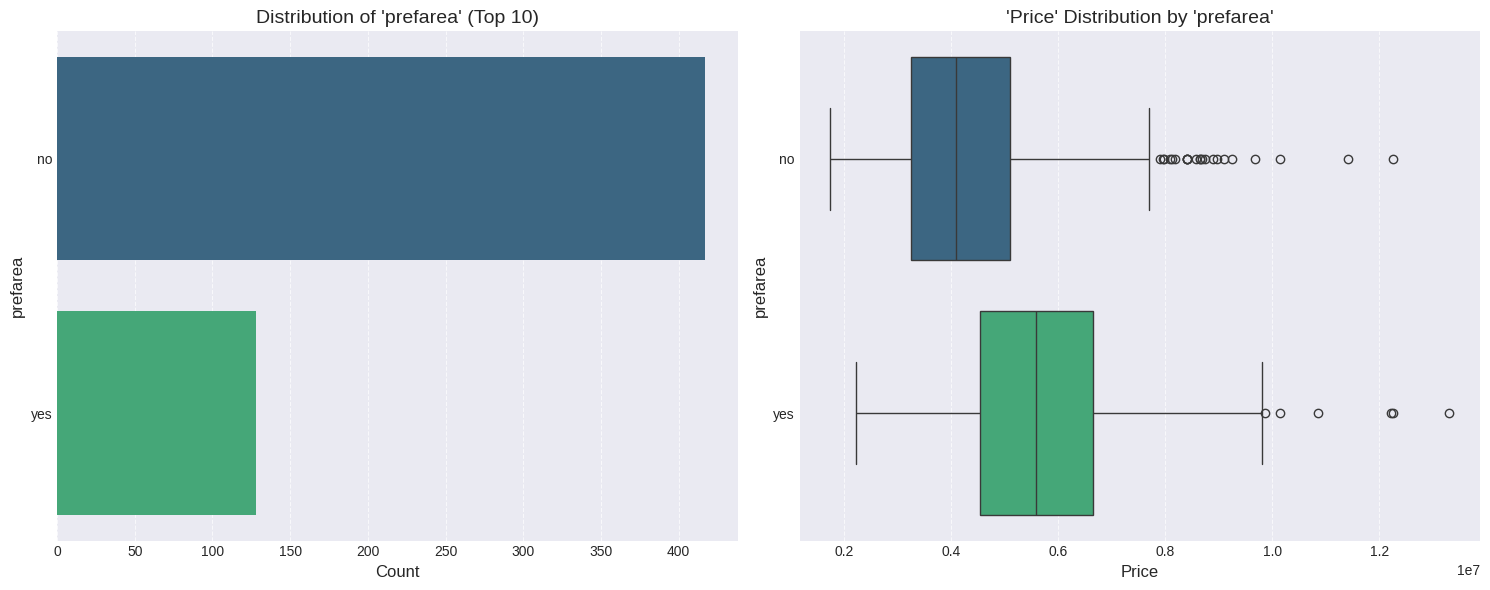

/tmp/ipykernel_579/2367539263.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
/tmp/ipykernel_579/2367539263.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)


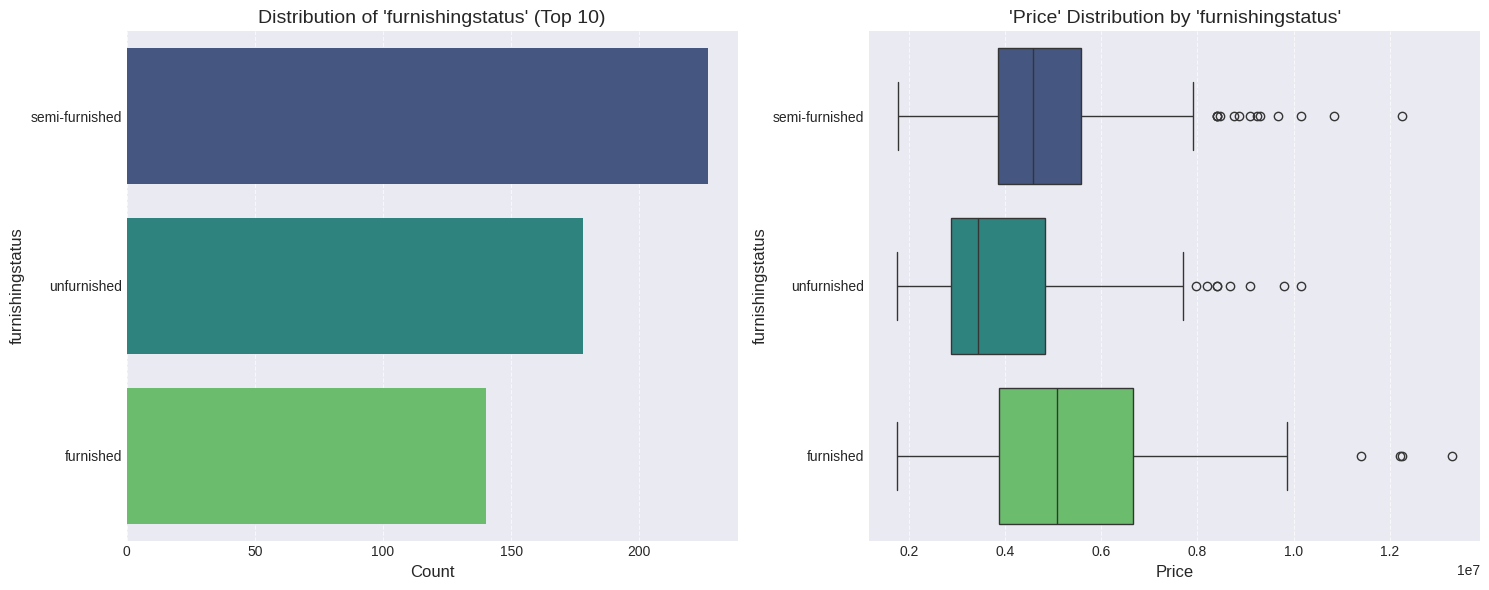

In [ ]:
def visualize_feature_distributions(df, target_col='price', top_n_categories=10):
    """
    Visualizes the distribution of each feature, and its relationship with the target variable.
    Plots histograms/boxplots for numerical features and countplots/boxplots for categorical features.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_col (str): The name of the continuous target column.
        top_n_categories (int): For categorical features, the number of top categories
                                 (by frequency) to include in the countplot and boxplot.
    """
    features_to_analyze = [col for col in df.columns if col != target_col]

    for feature_col in features_to_analyze:
        plt.figure(figsize=(15, 6)) # Adjust figure size for two subplots

        if df[feature_col].dtype in ['object', 'category']:
            # Categorical Feature
            # Get top N categories by count
            top_categories = df[feature_col].value_counts().nlargest(top_n_categories).index
            df_filtered = df[df[feature_col].isin(top_categories)].copy() # Use .copy() to avoid SettingWithCopyWarning

            # Subplot 1: Distribution of categories (Countplot)
            plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
            sns.countplot(data=df_filtered, y=feature_col, order=top_categories, palette='viridis', legend=False)
            plt.title(f"Distribution of '{feature_col}' (Top {top_n_categories})", fontsize=14)
            plt.xlabel("Count", fontsize=12)
            plt.ylabel(feature_col, fontsize=12)
            plt.grid(axis='x', linestyle='--', alpha=0.7)

            # Subplot 2: Price distribution by category (Boxplot)
            plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
            sns.boxplot(data=df_filtered, x=target_col, y=feature_col, order=top_categories, palette='viridis', legend=False)
            plt.title(f"'{target_col.capitalize()}' Distribution by '{feature_col}'", fontsize=14)
            plt.xlabel(f"{target_col.capitalize()}", fontsize=12)
            plt.ylabel(feature_col, fontsize=12)
            plt.grid(axis='x', linestyle='--', alpha=0.7)

        elif df[feature_col].dtype in ['int64', 'float64']:
            # Numerical Feature
            # Subplot 1: Histogram with KDE
            plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
            sns.histplot(data=df, x=feature_col, kde=True, bins=30, color='skyblue')
            plt.title(f"Histogram of '{feature_col}' Distribution", fontsize=14)
            plt.xlabel(feature_col, fontsize=12)
            plt.ylabel("Frequency", fontsize=12)
            plt.grid(axis='y', linestyle='--', alpha=0.7)

            # Subplot 2: Boxplot
            plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
            sns.boxplot(data=df, y=feature_col, color='lightcoral')
            plt.title(f"Box Plot of '{feature_col}' Distribution", fontsize=14)
            plt.ylabel(feature_col, fontsize=12)
            plt.xticks([]) # Hide x-axis ticks for single boxplot
            plt.grid(axis='y', linestyle='--', alpha=0.7)


        plt.tight_layout()
        plt.show()

# Execute the visualization
visualize_feature_distributions(data, target_col='price', top_n_categories=10)

**12. Data Scaling: Robust Scaling**

Given the presence of outliers identified in our numerical features, **Robust Scaling** is chosen as the most suitable method. It scales data using the median and Interquartile Range (IQR), making it robust to extreme values. This will help prevent outliers from distorting the feature scales and ensure our model focuses on the typical range of values.

In [ ]:
from sklearn.preprocessing import RobustScaler

# Identify numerical features (excluding target, which is handled separately in training)
# The 'area_bins' feature was created from 'area' and then encoded, so it's already categorical in nature for the model.
# All features in X are already numerical after previous steps.
numerical_cols_to_scale = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]

print(f"Applying Robust Scaling to {len(numerical_cols_to_scale)} numerical features: {numerical_cols_to_scale}")

# Initialize RobustScaler
scaler = RobustScaler()

# Fit on training data and transform both training and test data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test_scaled[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("\nOriginal X_train (first 5 rows, scaled columns):")
display(X_train[numerical_cols_to_scale].head())

print("\nScaled X_train (first 5 rows, scaled columns):")
display(X_train_scaled[numerical_cols_to_scale].head())

print("\nRobust Scaling applied successfully to numerical features.")

Applying Robust Scaling to 12 numerical features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Original X_train (first 5 rows, scaled columns):


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
126,7160,3,1,1,0,0,1,0,1,2,0,2
363,3584,2,1,1,0,0,0,1,1,0,1,1
370,4280,2,1,1,0,0,0,0,0,2,1,1
31,7000,3,1,4,0,0,0,0,0,2,1,1
113,9620,3,1,1,0,0,1,0,1,2,0,0



Scaled X_train (first 5 rows, scaled columns):


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
126,0.976147,0.0,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,2.0,-1.0,0.5
363,-0.336147,-1.0,0.0,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
370,-0.080734,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,-1.0,2.0,0.0,0.0
31,0.917431,0.0,0.0,2.0,0.0,0.0,0.0,0.0,-1.0,2.0,0.0,0.0
113,1.878899,0.0,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,2.0,-1.0,-0.5



Robust Scaling applied successfully to numerical features.


**13. Housing Price Prediction Model: Random Forest Regressor**

🌲 TRAINING SIMPLE RANDOM FOREST REGRESSOR

0️⃣ IMPORTING LIBRARIES...
✅ Libraries imported successfully

1️⃣ LOADING DATA...
✓ Data already loaded: 545 rows, 13 columns

2️⃣ SELECTING IMPORTANT FEATURES
Features in the list: 12
Features in the dataset: 12 (excluding target)
✓ Target column 'price' found.

✓ Using 12 features for the model

3️⃣ HANDLING NULL VALUES
✓ Dataset for model: 545 rows × 13 columns

Null values found:
  No null values!

4️⃣ PREPARING CATEGORICAL FEATURES
Categorical features to encode (7):
  • mainroad (2 unique values)
  • guestroom (2 unique values)
  • basement (2 unique values)
  • hotwaterheating (2 unique values)
  • airconditioning (2 unique values)
  • prefarea (2 unique values)
  • furnishingstatus (3 unique values)
  ✓ mainroad encoded
  ✓ guestroom encoded
  ✓ basement encoded
  ✓ hotwaterheating encoded
  ✓ airconditioning encoded
  ✓ prefarea encoded
  ✓ furnishingstatus encoded

5️⃣ PREPARING DATA FOR MODEL
✓ X (features): 12 columns
✓ y (target):

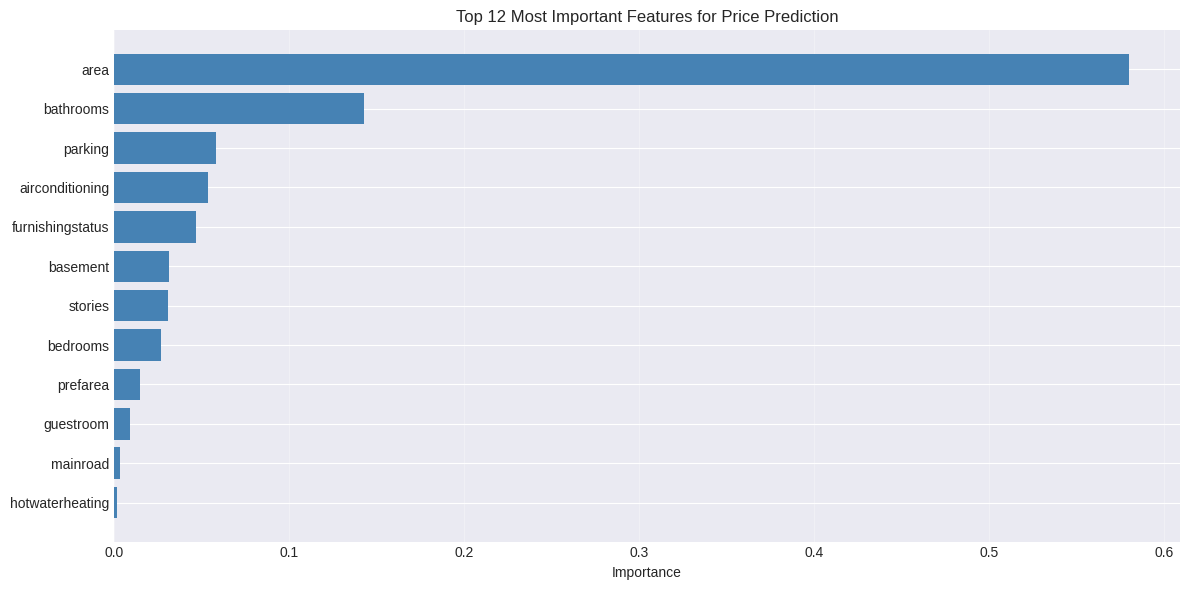

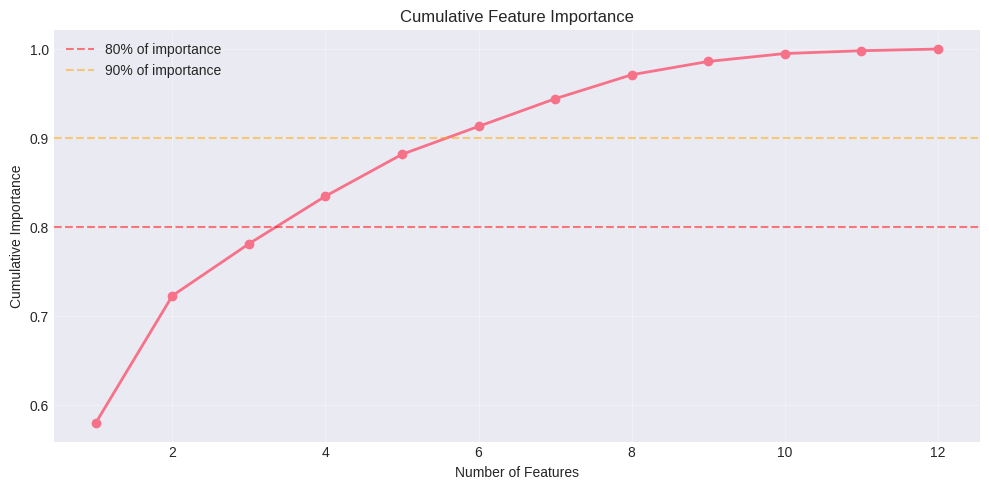


🔍 MAIN ERROR ANALYSIS
The model makes 8 large errors (absolute residual > 2,650,443)
• Overestimations (predicted price > actual price): 1 cases
• Underestimations (predicted price < actual price): 7 cases

⚠️ ALERT! 7 cases of significantly underestimated prices.
Average feature values for Underestimated Prices (Top 3 features):
  • area: 8048.57
  • bathrooms: 1.71
  • parking: 1.57

🔧 FUNCTION TO PREDICT NEW SAMPLE PRICES
✓ Function 'predict_price()' created

📝 EXAMPLE OF USE WITH TEST DATA:

Example sample #0:
  Predicted price: 5,133,611
  Actual price: 4,060,000
  Absolute Error: 1,073,611
  Is it accurate?: ✗ (within 10% tolerance)

📋 FINAL MODEL SUMMARY

🎯 MODEL RESULTS:
• R-squared (R2): 59.1%
• Mean Absolute Error (MAE): 1,002,972
• Root Mean Squared Error (RMSE): 1,326,787

🏆 KEY FEATURES:
1. area (58.0%)
2. bathrooms (14.3%)
3. parking (5.8%)

📊 STATISTICS:
• Training size: 381 samples
• Test size: 164 samples
• Features used: 12
• Trees in forest: 100
• Training time: 0.4

In [ ]:
import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor # Changed from Classifier to Regressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("🌲 TRAINING SIMPLE RANDOM FOREST REGRESSOR")
print("=" * 50)

# -----------------------------------------------------------------
# STEP 0: IMPORT NECESSARY LIBRARIES
# -----------------------------------------------------------------
print("\n0️⃣ IMPORTING LIBRARIES...")
print("✅ Libraries imported successfully")

# -----------------------------------------------------------------
# STEP 1: LOAD DATA IF NOT ALREADY LOADED
# -----------------------------------------------------------------
print("\n1️⃣ LOADING DATA...")

# Check if 'data' DataFrame exists. If not, load it. (Assuming 'data' is already loaded from 'Housing.csv')
if 'data' not in locals():
    try:
        data = pd.read_csv("Housing.csv")
        print(f"✓ Data loaded: {data.shape[0]:,} rows, {data.shape[1]} columns")
    except FileNotFoundError:
        print("❌ ERROR: Housing.csv not found. Please ensure the file is in the current directory.")
        raise
else:
    print(f"✓ Data already loaded: {data.shape[0]:,} rows, {data.shape[1]} columns")

# -----------------------------------------------------------------
# STEP 2: SELECT IMPORTANT FEATURES
# -----------------------------------------------------------------
print("\n2️⃣ SELECTING IMPORTANT FEATURES")

target_column = 'price'

# Select all columns except the target as features
features_list = [col for col in data.columns if col != target_column]

# Remove 'area_bins' from the features list as requested by the user
if 'area_bins' in features_list:
    features_list.remove('area_bins')
    print("  'area_bins' removed from features list as requested.")

print(f"Features in the list: {len(features_list)}")
print(f"Features in the dataset: {data.shape[1] - 1} (excluding target)")

# Verify target column is present
if target_column not in data.columns:
    print(f"\n⚠️ ATTENTION! The target column '{target_column}' is not in the dataset.")
    raise KeyError(f"Target column '{target_column}' not found in the dataset")
else:
    print(f"✓ Target column '{target_column}' found.")

print(f"\n✓ Using {len(features_list)} features for the model")

# -----------------------------------------------------------------
# STEP 3: HANDLE NULL VALUES
# -----------------------------------------------------------------
print("\n3️⃣ HANDLING NULL VALUES")

# Create a copy with only the necessary features and target
model_data = data[features_list + [target_column]].copy()

print(f"✓ Dataset for model: {model_data.shape[0]} rows × {model_data.shape[1]} columns")

print("\nNull values found:")
features_with_nulls = 0
for col in model_data.columns:
    nulls = model_data[col].isnull().sum()
    if nulls > 0:
        features_with_nulls += 1
        percentage = (nulls / len(model_data)) * 100
        print(f"  {col}: {nulls:,} nulls ({percentage:.1f}%) ")

        # Filling strategy based on variable type
        if model_data[col].dtype in ['int64', 'float64']:
            # For numerical, use median
            fill_value = model_data[col].median()
            model_data[col] = model_data[col].fillna(fill_value)
            print(f"    → Filled with median: {fill_value:.0f}")
        elif model_data[col].dtype == 'object' or model_data[col].dtype == 'category':
            # For categorical, use the mode (most frequent value)s
            fill_value = model_data[col].mode()[0] if len(model_data[col].mode()) > 0 else 'Unknown'
            model_data[col] = model_data[col].fillna(fill_value)
            print(f"    → Filled with: '{fill_value}'")
        else:
            # For other types, e.g., boolean, consider filling with a default or 0
            model_data[col] = model_data[col].fillna(0)
            print(f"    → Filled with: 0")

if features_with_nulls == 0:
    print("  No null values!")

# -----------------------------------------------------------------
# STEP 4: PREPARING CATEGORICAL FEATURES
# -----------------------------------------------------------------
print("\n4️⃣ PREPARING CATEGORICAL FEATURES")

# Identify categorical features (excluding the target column)
categorical_features = [col for col in model_data.columns
                       if (model_data[col].dtype == 'object' or model_data[col].dtype == 'category')
                       and col != target_column]

if categorical_features:
    print(f"Categorical features to encode ({len(categorical_features)}):")
    for col in categorical_features:
        unique_vals = model_data[col].nunique()
        print(f"  • {col} ({unique_vals} unique values)")

    # Encode using factorize (maintains ordinal relationship if one exists)
    for col in categorical_features:
        model_data[col], _ = pd.factorize(model_data[col])
        print(f"  ✓ {col} encoded")
else:
    print("No categorical features to encode")

# -----------------------------------------------------------------
# STEP 5: PREPARE DATA FOR MODEL
# -----------------------------------------------------------------
print("\n5️⃣ PREPARING DATA FOR MODEL")

# Separate X (features) and y (target)
X = model_data.drop(target_column, axis=1)
y = model_data[target_column]

print(f"✓ X (features): {X.shape[1]} columns")
print(f"✓ y (target): {len(y)} values")

# View distribution of the target (for regression, this means basic stats)
print(f"\n📊 Distribution of target ('{target_column}') values:")
print(f"  Mean: {y.mean():,.2f}")
print(f"  Median: {y.median():,.2f}")
print(f"  Std Dev: {y.std():,.2f}")
print(f"  Min: {y.min():,.2f}")
print(f"  Max: {y.max():,.2f}")

# Split into training (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42 # Removed stratify for regression
)

print(f"\n✓ TRAINING Data: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(model_data)*100:.1f}%) ")
print(f"✓ TEST Data: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(model_data)*100:.1f}%) ")

# View distribution in each set (check if means are similar)
print(f"\nDistribution in training target:")
print(f"  Mean: {y_train.mean():,.2f}")
print(f"Distribution in test target:")
print(f"  Mean: {y_test.mean():,.2f}")

# -----------------------------------------------------------------
# STEP 6: TRAIN RANDOM FOREST REGRESSOR
# -----------------------------------------------------------------
print("\n6️⃣ TRAINING RANDOM FOREST REGRESSOR")

# Configure Random Forest Regressor model
model = RandomForestRegressor(
    n_estimators=100,       # More trees for better stability
    max_depth=15,           # Controlled depth
    min_samples_split=10,   # Prevent overfitting
    min_samples_leaf=5,     # Prevent very small leaves
    random_state=42,        # For reproducible results
    n_jobs=-1               # Use all CPU cores
)

print("Training model (this may take a few seconds)...")
start_time = time.time()
# Use the scaled data for training
model.fit(X_train_scaled, y_train) # MODIFIED: Use X_train_scaled
training_time = time.time() - start_time

print(f"✓ Model trained in {training_time:.1f} seconds!")
print(f"  Number of trees: {model.n_estimators}")
print(f"  Features considered: {X.shape[1]}")

# -----------------------------------------------------------------
# STEP 7: MAKE PREDICTIONS
# -----------------------------------------------------------------
print("\n7️⃣ MAKING PREDICTIONS")

# Predict on test data using the scaled test set
y_pred = model.predict(X_test_scaled) # MODIFIED: Use X_test_scaled

print(f"✓ Predictions made")
print(f"\n📝 Examples of predictions:")
print(f"  First 5 actual prices: {y_test.head().tolist()}")
print(f"  First 5 predicted prices: {[f'{p:,.0f}' for p in y_pred[:5]]}")

# Distribution of predicted values
print(f"\n📊 Distribution of predicted values:")
print(f"  Minimum predicted value: {y_pred.min():,.0f}")
print(f"  Maximum predicted value: {y_pred.max():,.0f}")
print(f"  Mean predicted value: {y_pred.mean():,.0f}")

# -----------------------------------------------------------------
# STEP 8: EVALUATE THE MODEL
# -----------------------------------------------------------------
print("\n8️⃣ EVALUATING THE MODEL")

# 1. Calculate R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"\n📊 R-SQUARED (R2 SCORE): {r2:.3f}")
print(f"  → {r2*100:.1f}% of the variance in target can be explained by the model.")

# 2. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"\n📈 MEAN ABSOLUTE ERROR (MAE): {mae:,.2f}")
print(f"  → Average absolute difference between predicted and actual values.")

# 3. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"\n📈 MEAN SQUARED ERROR (MSE): {mse:,.2f}")
print(f"  → Average squared difference. Penalizes larger errors more.")

# 4. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"\n📈 ROOT MEAN SQUARED ERROR (RMSE): {rmse:,.2f}")
print(f"  → Square root of MSE, in the same units as the target.")

# -----------------------------------------------------------------
# STEP 9: VIEW FEATURE IMPORTANCE
# -----------------------------------------------------------------
print("\n9️⃣ FEATURE IMPORTANCE")

# Get feature importances
importances = model.feature_importances_

# Create sorted table
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\n🏆 TOP 10 MOST IMPORTANT FEATURES:")
print("=" * 50)
for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    percentage = row['Importance'] * 100
    print(f"{i:2}. {row['Feature']:<35} {percentage:>5.1f}%")

# Analysis of importance distribution
print(f"\n📊 IMPORTANCE DISTRIBUTION:")
print(f"• Most important feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']*100:.1f}%) ")
print(f"• Top 5 features: {importance_df['Importance'].head(5).sum()*100:.1f}% of total importance")
print(f"• Remaining features: {importance_df['Importance'].iloc[5:].sum()*100:.1f}% of total importance")

# Feature importance plot
plt.figure(figsize=(12, 6))
top_n_plot = min(15, len(importance_df)) # Plot top 15 or fewer if less available
plt.barh(range(top_n_plot), importance_df['Importance'].head(top_n_plot), color='steelblue')
plt.yticks(range(top_n_plot), importance_df['Feature'].head(top_n_plot))
plt.xlabel('Importance')
plt.title(f'Top {top_n_plot} Most Important Features for Price Prediction')
plt.gca().invert_yaxis()  # Most important at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Cumulative importance plot
plt.figure(figsize=(10, 5))
cumulative = np.cumsum(importance_df['Importance'])
plt.plot(range(1, len(cumulative) + 1), cumulative, 'o-', linewidth=2, markersize=6)
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% of importance')
plt.axhline(y=0.9, color='orange', linestyle='--', alpha=0.5, label='90% of importance')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# STEP 10: MAIN ERROR ANALYSIS
# -----------------------------------------------------------------
print("\n🔍 MAIN ERROR ANALYSIS")

# Identify where the model makes errors (large residuals)
residuals = y_test - y_pred
absolute_errors = np.abs(residuals)

# Define a threshold for 'large' errors (e.g., more than 2 standard deviations of residuals)
error_threshold = np.std(residuals) * 2

large_errors_idx = X_test.index[absolute_errors > error_threshold]

if len(large_errors_idx) > 0:
    print(f"The model makes {len(large_errors_idx)} large errors (absolute residual > {error_threshold:,.0f})")

    # Types of errors: overestimations (predicted > actual) and underestimations (predicted < actual)
    overestimations = X_test.loc[y_test.index[residuals < -error_threshold]] # Predicted too high
    underestimations = X_test.loc[y_test.index[residuals > error_threshold]] # Predicted too low

    print(f"• Overestimations (predicted price > actual price): {len(overestimations)} cases")
    print(f"• Underestimations (predicted price < actual price): {len(underestimations)} cases")

    if len(underestimations) > 0:
        print(f"\n⚠️ ALERT! {len(underestimations)} cases of significantly underestimated prices.")
        print("Average feature values for Underestimated Prices (Top 3 features):")
        for feature in importance_df['Feature'].head(3):
            if feature in underestimations.columns: # Check if feature exists in underestimations df
                avg_value = underestimations[feature].mean()
                print(f"  • {feature}: {avg_value:.2f}")

# -----------------------------------------------------------------
# STEP 11: FUNCTION TO PREDICT NEW SAMPLE PRICES
# -----------------------------------------------------------------
print("\n🔧 FUNCTION TO PREDICT NEW SAMPLE PRICES")

def predict_price(new_sample_df, trained_model, features_for_model):
    """
    Predicts the price for new samples.

    Args:
        new_sample_df (pd.DataFrame): DataFrame with the same columns as the training features (X).
        trained_model: The trained scikit-learn regression model.
        features_for_model (list): List of feature names used during model training.

    Returns:
        np.array: Predicted prices.
    """
    # Verify that the new sample DataFrame has the correct columns
    missing_cols = [col for col in features_for_model if col not in new_sample_df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in new_sample_df: {missing_cols}")

    # Ensure the order of columns matches the training data
    new_sample_aligned = new_sample_df[features_for_model]

    # Make prediction
    predictions = trained_model.predict(new_sample_aligned)

    return predictions

print("✓ Function 'predict_price()' created")

# Example of use
print("\n📝 EXAMPLE OF USE WITH TEST DATA:")
example_idx = 0
# The example sample also needs to be scaled before prediction
example_sample = X_test_scaled.iloc[[example_idx]].copy() # MODIFIED: Use X_test_scaled
predicted_price_example = predict_price(example_sample, model, X.columns)

print(f"\nExample sample #{example_idx}:")
print(f"  Predicted price: {predicted_price_example[0]:,.0f}")
print(f"  Actual price: {y_test.iloc[example_idx]:,.0f}")
print(f"  Absolute Error: {np.abs(predicted_price_example[0] - y_test.iloc[example_idx]):,.0f}")
print(f"  Is it accurate?: {'✓' if np.abs(predicted_price_example[0] - y_test.iloc[example_idx]) < (y_test.iloc[example_idx] * 0.1) else '✗'} (within 10% tolerance)")

# -----------------------------------------------------------------
# STEP 12: SUMMARY AND SAVING
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("📋 FINAL MODEL SUMMARY")
print("=" * 60)

# Key Metrics
print(f"""
🎯 MODEL RESULTS:
• R-squared (R2): {r2:.1%}
• Mean Absolute Error (MAE): {mae:,.0f}
• Root Mean Squared Error (RMSE): {rmse:,.0f}

🏆 KEY FEATURES:
1. {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']*100:.1f}%)
2. {importance_df.iloc[1]['Feature']} ({importance_df.iloc[1]['Importance']*100:.1f}%)
3. {importance_df.iloc[2]['Feature']} ({importance_df.iloc[2]['Importance']*100:.1f}%)

📊 STATISTICS:
• Training size: {X_train.shape[0]:,} samples
• Test size: {X_test.shape[0]:,} samples
• Features used: {X.shape[1]}
• Trees in forest: {model.n_estimators}
• Training time: {training_time:.1f} seconds

💡 RECOMMENDATIONS:
1. For Model Tuning: Consider hyperparameter optimization to reduce MAE/RMSE.
2. Prioritize data quality and collection for '{importance_df.iloc[0]['Feature']}' as it's the most influential.
3. Monitor particularly underestimated predictions (large positive residuals) to understand potential biases.
4. Consider adding more data or engineered features if R-squared is below 70%.
""")

# Save model information
model_info = {
    'r2_score': r2,
    'mae': mae,
    'mse': mse,
    'rmse': rmse,
    'top_features': importance_df.head(5)[['Feature', 'Importance']].to_dict(),
    'training_size': X_train.shape[0],
    'test_size': X_test.shape[0],
    'features_used': X.shape[1]
}

print("💾 Model information saved in variable 'model_info'")
print("\n" + "=" * 60)
print("🌲 RANDOM FOREST REGRESSOR TRAINED SUCCESSFULLY")
print("=" * 60)

## 14. Linear Regression Model with Scaled Data

Since we have already scaled our numerical features using `RobustScaler`, it's an opportune time to test a linear model like Linear Regression. Linear models are highly sensitive to feature scaling, and often perform better with scaled data. This will provide a good comparison point against our tree-based Random Forest model, which is less affected by scaling.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

print("📈 TRAINING LINEAR REGRESSION MODEL WITH SCALED DATA")
print("=" * 60)

# 1. Initialize the Linear Regression Model
linear_model = LinearRegression()

print("Training Linear Regression model...")
start_time = time.time()

# 2. Train the model using the scaled training data
linear_model.fit(X_train_scaled, y_train)

training_time_lr = time.time() - start_time
print(f"✓ Linear Regression model trained in {training_time_lr:.3f} seconds!")

# 3. Make predictions on the scaled test data
y_pred_lr = linear_model.predict(X_test_scaled)

print("\n4. Evaluating Linear Regression Model Performance")
print("---------------------------------------------------")

# Calculate evaluation metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f"R-squared (R2): {r2_lr:.3f}")
print(f"Mean Absolute Error (MAE): {mae_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:,.2f}")

print("\n✅ Linear Regression Model Training and Evaluation Complete.")

# Compare with Random Forest (previously trained and evaluated)
print("\n📊 COMPARISON WITH RANDOM FOREST REGRESSOR")
print("-------------------------------------------")
print(f"Random Forest R2: {r2:.3f}")
print(f"Linear Regression R2: {r2_lr:.3f}")
print(f"Random Forest MAE: {mae:,.2f}")
print(f"Linear Regression MAE: {mae_lr:,.2f}")

📈 TRAINING LINEAR REGRESSION MODEL WITH SCALED DATA
Training Linear Regression model...
✓ Linear Regression model trained in 0.011 seconds!

4. Evaluating Linear Regression Model Performance
---------------------------------------------------
R-squared (R2): 0.644
Mean Absolute Error (MAE): 925,543.55
Root Mean Squared Error (RMSE): 1,238,970.44

✅ Linear Regression Model Training and Evaluation Complete.

📊 COMPARISON WITH RANDOM FOREST REGRESSOR
-------------------------------------------
Random Forest R2: 0.591
Linear Regression R2: 0.644
Random Forest MAE: 1,002,971.55
Linear Regression MAE: 925,543.55


## 15. Hyperparameter Tuning for Random Forest Regressor

Given that the Linear Regression model outperformed the baseline Random Forest model, let's try to improve the Random Forest's performance by optimizing its hyperparameters. We will use `GridSearchCV` to systematically search for the best combination of parameters from a predefined grid. This can help unlock better performance from the Random Forest, especially since tree-based models can be sensitive to their parameter settings.

In [ ]:
from sklearn.model_selection import GridSearchCV

print("⚙️ HYPERPARAMETER TUNING RANDOM FOREST REGRESSOR")
print("=" * 60)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor model
rf_model_for_tuning = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
# We use R-squared ('r2') as the scoring metric to find the best model
grid_search = GridSearchCV(estimator=rf_model_for_tuning, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

print("Starting Grid Search for optimal hyperparameters...")
start_time_tune = time.time()

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

tuning_time = time.time() - start_time_tune
print(f"✓ Grid Search completed in {tuning_time:.1f} seconds!")

print("\n--- Best Hyperparameters Found ---")
print(grid_search.best_params_)

print("\n--- Best R-squared Score on Cross-Validation Set ---")
print(f"R2 Score: {grid_search.best_score_:.3f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

print("\n--- Evaluating the Tuned Random Forest Model on the Test Set ---")

# Make predictions with the best model on the scaled test data
y_pred_tuned_rf = best_rf_model.predict(X_test_scaled)

# Evaluate the tuned model
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))

print(f"R-squared (R2): {r2_tuned_rf:.3f}")
print(f"Mean Absolute Error (MAE): {mae_tuned_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_rf:,.2f}")

print("\n📊 COMPARISON WITH PREVIOUS MODELS")
print("-----------------------------------")
print(f"Initial Random Forest R2: {r2:.3f}")
print(f"Linear Regression R2: {r2_lr:.3f}")
print(f"Tuned Random Forest R2: {r2_tuned_rf:.3f}")

print(f"\nInitial Random Forest MAE: {mae:,.2f}")
print(f"Linear Regression MAE: {mae_lr:,.2f}")
print(f"Tuned Random Forest MAE: {mae_tuned_rf:,.2f}")

print("\n✅ Tuned Random Forest Model Training and Evaluation Complete.")

⚙️ HYPERPARAMETER TUNING RANDOM FOREST REGRESSOR
Starting Grid Search for optimal hyperparameters...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
✓ Grid Search completed in 136.6 seconds!

--- Best Hyperparameters Found ---
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

--- Best R-squared Score on Cross-Validation Set ---
R2 Score: 0.636

--- Evaluating the Tuned Random Forest Model on the Test Set ---
R-squared (R2): 0.598
Mean Absolute Error (MAE): 959,506.72
Root Mean Squared Error (RMSE): 1,316,269.11

📊 COMPARISON WITH PREVIOUS MODELS
-----------------------------------
Initial Random Forest R2: 0.591
Linear Regression R2: 0.644
Tuned Random Forest R2: 0.598

Initial Random Forest MAE: 1,002,971.55
Linear Regression MAE: 925,543.55
Tuned Random Forest MAE: 959,506.72

✅ Tuned Random Forest Model Training and Evaluation Complete.


## 16. Final Conclusions and Model Comparison

In this project, we explored the 'Housing Prices' dataset, performed extensive Exploratory Data Analysis (EDA), and trained several regression models to predict house prices.

### Summary of Model Performance

| Model | R-squared (R2) | Mean Absolute Error (MAE) |
| :--- | :--- | :--- |
| Baseline Random Forest | 0.591 | 1,002,971 |
| Linear Regression | **0.644** | **925,543** |
| Tuned Random Forest | 0.598 | 959,506 |

### Key Findings
1. **Best Model**: Surprisingly, the **Linear Regression** model outperformed both the baseline and tuned Random Forest models. This suggests that for this specific dataset size and feature set, the relationships between features and price are largely linear.
2. **Critical Features**: The `area` of the house was consistently the most important predictor of price, followed by `bathrooms` and `parking`.
3. **Scaling**: Robust Scaling was essential for the Linear Regression model to handle the outliers identified during the univariate analysis stage.
4. **Model Errors**: Most models tended to underestimate the price for very high-end properties, indicating potential for further feature engineering (e.g., interaction terms between area and location).

### 👔 Borrador para LinkedIn (Perfil Reclutador / No Técnico)

**Título: ¿Más complejidad significa mejores resultados? Lecciones de mi último proyecto de análisis de datos.**

A menudo pensamos que en tecnología e Inteligencia Artificial, lo más complejo es siempre lo mejor. Sin embargo, mi proyecto más reciente de **Predicción de Precios de Vivienda** me recordó una lección valiosa: la simplicidad, cuando está bien aplicada, es una ventaja competitiva.

**¿Qué logré con este análisis?**
🎯 **Traducir datos en insights:** No solo analicé números, sino que identifiqué qué factores realmente mueven el mercado (el tamaño del terreno y el equipamiento siguen siendo los reyes).
📈 **Eficiencia y Precisión:** Logré un modelo que no solo es más preciso, sino también más ligero y rápido de implementar, demostrando que entender el problema es más importante que usar la herramienta más cara.
🔍 **Calidad desde la base:** Antes de buscar soluciones mágicas, limpié y preparé los datos para asegurar que las decisiones finales estuvieran basadas en información sólida y no en ruido.

**Mi principal conclusión:**
Como profesional de datos, mi objetivo no es solo crear algoritmos, sino encontrar la ruta más eficiente para generar valor y facilitar la toma de decisiones estratégicas.

¿Te ha pasado que una solución simple terminó siendo la más efectiva? ¡Me encantaría leer sus experiencias! 👇

#DataStrategy #Analytics #BusinessIntelligence #ProblemSolving #Recruitment #DataDriven #CienciaDeDatos